## **Imports & Configuration**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
np.random.seed(42)  # Pour la reproductibilité

# **1. CHARGEMENT ET EXPLORATION DES DONNÉES**

In [2]:
# Chargement du dataset
df = pd.read_csv('dataCancer.csv')

In [3]:
print(f"  Nombre de patients : {len(df)}")
print(f"  Nombre de colonnes : {len(df.columns)}")
print(f"  Colonnes : {list(df.columns)}")
print(f'  Types de données     : {df.dtypes.value_counts().to_dict()}')
print(f'  Valeurs manquantes   : {df.isnull().sum().sum()} (toutes dans la colonne \'Unnamed: 32\')')
print(f'  Doublons             : {df.duplicated().sum()}')
print()


  Nombre de patients : 569
  Nombre de colonnes : 33
  Colonnes : ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
  Types de données     : {dtype('float64'): 31, dtype('int64'): 1, dtype('O'): 1}
  Valeurs manquantes   : 569 (toutes dans la colonne 'Unnamed: 32')
  Doublons             : 0



In [4]:
print("DISTRIBUTION DU DIAGNOSTIC :")
diagnostic_counts = df['diagnosis'].value_counts()
for label, count in diagnostic_counts.items():
    name = 'Bénigne (B)' if label == 'B' else 'Maligne (M)'
    pct = count/len(df)*100
    print(f"   • {name} : {count} patients ({pct:.1f}%)")
print()
df.head(4)

DISTRIBUTION DU DIAGNOSTIC :
   • Bénigne (B) : 357 patients (62.7%)
   • Maligne (M) : 212 patients (37.3%)



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN


## **Nettoyage & Préparation**

In [5]:
# Suppression de colonnes inutiles
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encodage de la cible : M=0 (Maligne), B=1 (Bénigne)
df['target'] = (df['diagnosis'] == 'B').astype(int)

# Colonnes features
FEAT_COLS = [c for c in df.columns if c not in ['diagnosis', 'target']]

print('═'*60)
print('  RAPPORT DE NETTOYAGE')
print('═'*60)
print(f'  Colonne "id"          : supprimée  (identifiant unique, non informatif)')
print(f'  Colonne "Unnamed: 32" : supprimée  (colonne vide : 569/569 NaN)')
print(f'  Encodage cible        : M=0 (Maligne), B=1 (Bénigne)')
print(f'  Valeurs manquantes    : {df.isnull().sum().sum()}')
print(f'  Doublons              : {df.duplicated().sum()}')
print(f'  Nombre de features    : {len(FEAT_COLS)} features numériques')



════════════════════════════════════════════════════════════
  RAPPORT DE NETTOYAGE
════════════════════════════════════════════════════════════
  Colonne "id"          : supprimée  (identifiant unique, non informatif)
  Colonne "Unnamed: 32" : supprimée  (colonne vide : 569/569 NaN)
  Encodage cible        : M=0 (Maligne), B=1 (Bénigne)
  Valeurs manquantes    : 0
  Doublons              : 0
  Nombre de features    : 30 features numériques


In [6]:
# Détection d'outliers (IQR) sur les features clés
print(f'\n  Détection d\'outliers (méthode IQR) :')
print(f'  {"Feature":<28} {"N outliers":>12} {"% du dataset":>14}')
print('  ' + '-'*56)
for feat in ['radius_mean', 'area_mean', 'concavity_mean', 'concave points_mean']:
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f'  {feat:<28} {n_out:>12} {n_out/len(df)*100:>13.1f}%')
print(f'\n  → Décision : outliers CONSERVÉS.')

print(f'    Justification clinique : ces valeurs extrêmes représentent')
print(f'    des tumeurs réellement anormales. Les supprimer biaiserait')
print(f'    le modèle et nuirait à la détection de cas graves.')


  Détection d'outliers (méthode IQR) :
  Feature                        N outliers   % du dataset
  --------------------------------------------------------
  radius_mean                            14           2.5%
  area_mean                              25           4.4%
  concavity_mean                         18           3.2%
  concave points_mean                    10           1.8%

  → Décision : outliers CONSERVÉS.
    Justification clinique : ces valeurs extrêmes représentent
    des tumeurs réellement anormales. Les supprimer biaiserait
    le modèle et nuirait à la détection de cas graves.


In [7]:
#Split train/test
X = df[FEAT_COLS].values
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
# Normalisation StandardScaler (μ=0, σ=1)
# FIT uniquement sur train → évite la fuite de données (data leakage)
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print('═'*60)
print('  SPLIT TRAIN / TEST  (stratifié)')
print('═'*60)
print(f'  Total dataset : {len(X)} patients')
print(f'  Train (80%)   : {len(X_train)} patients')
print(f'  Test  (20%)   : {len(X_test)}  patients')
print()
for sname, ysp in [('Train', y_train), ('Test', y_test)]:
    n_b = (ysp==1).sum(); n_m = (ysp==0).sum()
    print(f'  {sname} → Bénigne: {n_b} ({n_b/len(ysp)*100:.1f}%)   Maligne: {n_m} ({n_m/len(ysp)*100:.1f}%)')

print()

print('  Normalisation StandardScaler :')
fi = FEAT_COLS.index('radius_mean')
print(f'  radius_mean avant  : μ={X_train[:,fi].mean():.3f},  σ={X_train[:,fi].std():.3f}')
print(f'  radius_mean après  : μ={X_train_s[:,fi].mean():.4f}, σ={X_train_s[:,fi].std():.4f}  ')

════════════════════════════════════════════════════════════
  SPLIT TRAIN / TEST  (stratifié)
════════════════════════════════════════════════════════════
  Total dataset : 569 patients
  Train (80%)   : 426 patients
  Test  (20%)   : 143  patients

  Train → Bénigne: 267 (62.7%)   Maligne: 159 (37.3%)
  Test → Bénigne: 90 (62.9%)   Maligne: 53 (37.1%)

  Normalisation StandardScaler :
  radius_mean avant  : μ=14.075,  σ=3.505
  radius_mean après  : μ=-0.0000, σ=1.0000  


# **3-Analyse Exploratoire (EDA)**

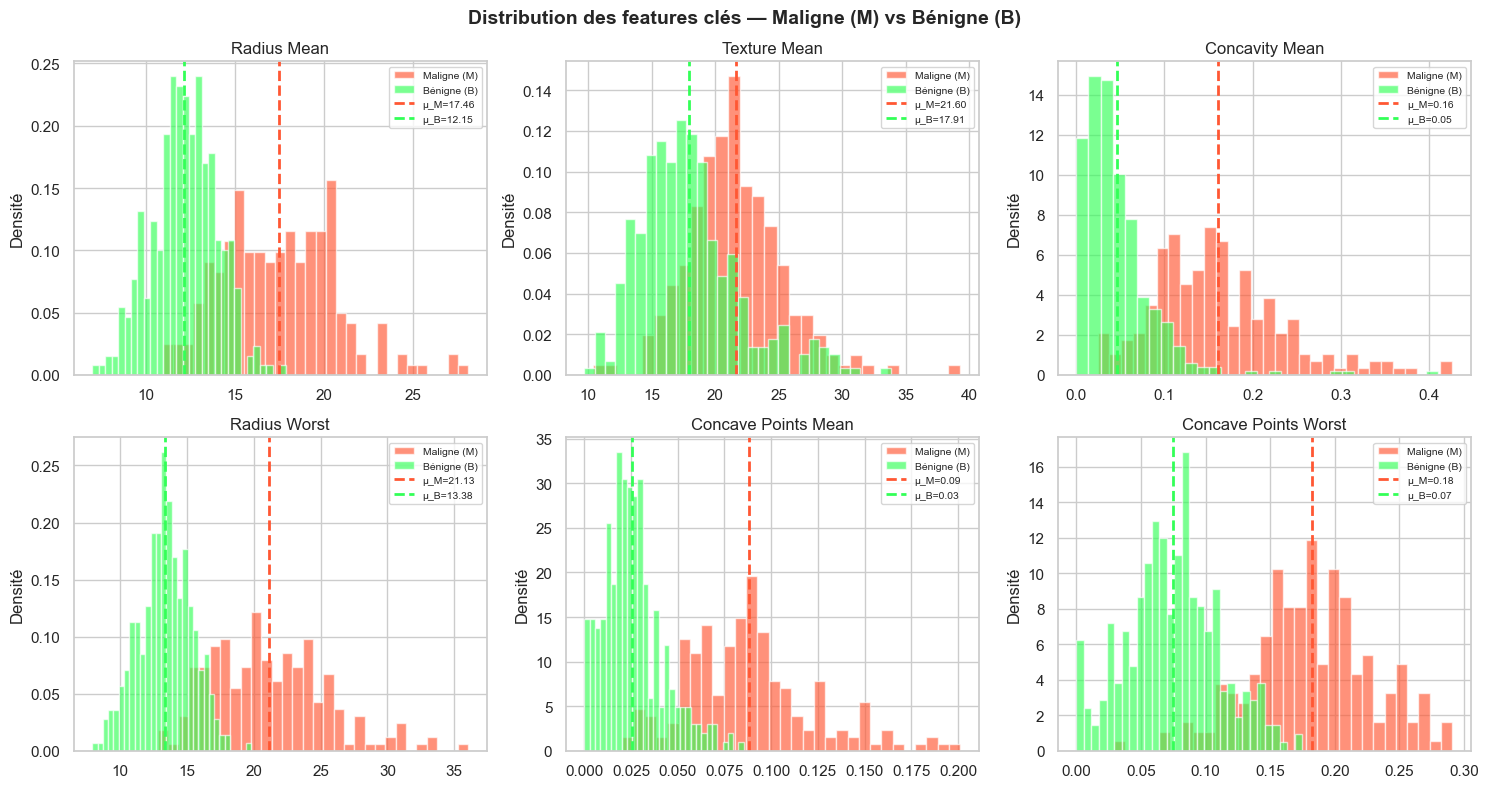

→ Les tumeurs malignes ont systématiquement des valeurs plus élevées
  de rayon, concavité et points concaves → ces features sont très discriminantes.


In [8]:
key_feats = [
    'radius_mean', 'texture_mean', 'concavity_mean',
    'radius_worst', 'concave points_mean', 'concave points_worst'
]

# Define colors for plots
C_MAL = '#FF5733'  # Malignant color (e.g., a shade of red/orange)
C_BEN = '#33FF57'  # Benign color (e.g., a shade of green)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution des features clés — Maligne (M) vs Bénigne (B)', fontsize=14, fontweight='bold')
axes = axes.flatten()

df_m = df[df['diagnosis'] == 'M']
df_b = df[df['diagnosis'] == 'B']

for i, feat in enumerate(key_feats):
    axes[i].hist(df_m[feat], bins=30, density=True, alpha=0.65, color=C_MAL, label='Maligne (M)', edgecolor='white')
    axes[i].hist(df_b[feat], bins=30, density=True, alpha=0.65, color=C_BEN, label='Bénigne (B)', edgecolor='white')
    axes[i].axvline(df_m[feat].mean(), color=C_MAL, linestyle='--', linewidth=2, label=f'μ_M={df_m[feat].mean():.2f}')
    axes[i].axvline(df_b[feat].mean(), color=C_BEN, linestyle='--', linewidth=2, label=f'μ_B={df_b[feat].mean():.2f}')
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=140, bbox_inches='tight')
plt.show()
print('→ Les tumeurs malignes ont systématiquement des valeurs plus élevées')
print('  de rayon, concavité et points concaves → ces features sont très discriminantes.')

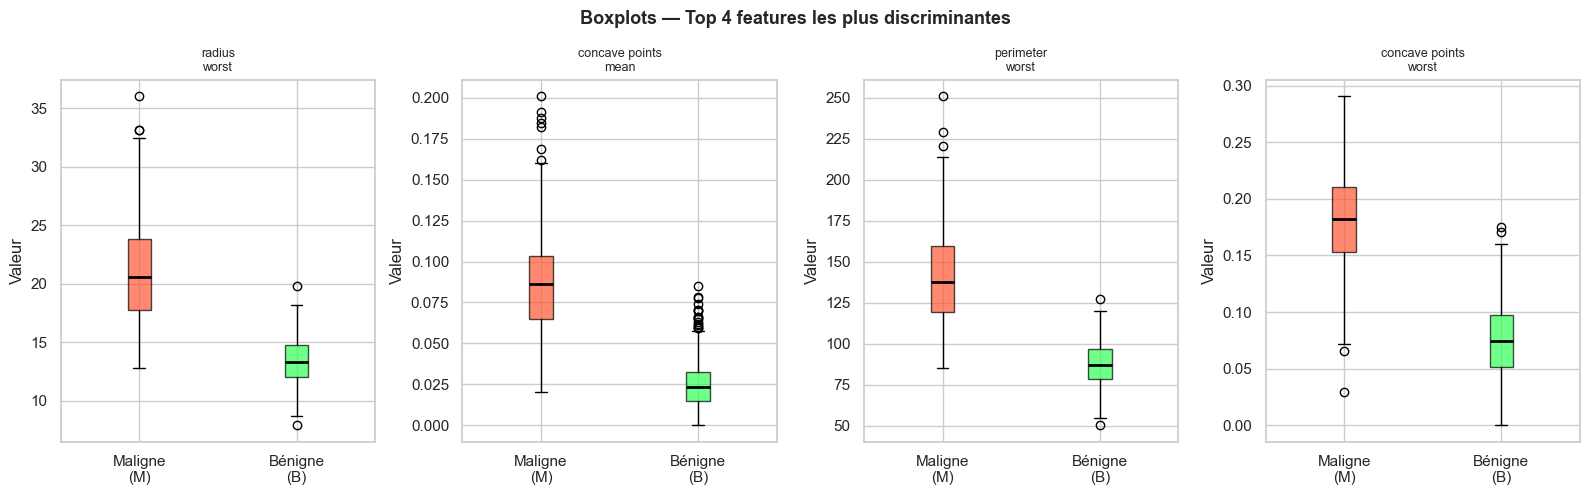

In [9]:
# ── 3.3  Boxplots comparatifs ──────────────────────────────────
# Calculate correlation with target
corr_target = df[FEAT_COLS].corrwith(df['target']).abs().sort_values()
top4_feats = list(corr_target.tail(4).index)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Boxplots — Top 4 features les plus discriminantes', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top4_feats):
    data_m = df_m[feat].values
    data_b = df_b[feat].values
    bp = ax.boxplot([data_m, data_b],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    labels=['Maligne\n(M)', 'Bénigne\n(B)'])
    bp['boxes'][0].set_facecolor(C_MAL)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(C_BEN)
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('Valeur')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
# =============================================================================
# FORMULE DE BAYES MANUELLE
# Exemple : Probabilité qu'une tumeur soit maligne si radius_mean > seuil
# =============================================================================

import numpy as np

# -------------------------------
# Paramètre choisi
# -------------------------------
seuil = 15.0  # seuil du radius_mean

# -------------------------------
# ÉTAPE 0 : Informations dataset
# -------------------------------
N_total = len(df)

N_M = (df['diagnosis'] == 'M').sum()  # Maligne
N_B = (df['diagnosis'] == 'B').sum()  # Bénigne


# -------------------------------
# ÉTAPE 1 : Probabilités a priori
# -------------------------------
P_M = N_M / N_total
P_B = N_B / N_total


# -------------------------------
# ÉTAPE 2 : Vraisemblances
# -------------------------------
P_R_M = (df[df['diagnosis'] == 'M']['radius_mean'] > seuil).mean()

P_R_B = (df[df['diagnosis'] == 'B']['radius_mean'] > seuil).mean()


# -------------------------------
# ÉTAPE 3 : Évidence
# -------------------------------
P_R = P_R_M * P_M + P_R_B * P_B


# -------------------------------
# ÉTAPE 4 : Posterior (Bayes)
# -------------------------------
P_M_given_R = (P_R_M * P_M) / P_R
P_B_given_R = (P_R_B * P_B) / P_R


# =============================================================================
# AFFICHAGE DES RÉSULTATS
# =============================================================================

print("===============================================")
print("THÉORÈME DE BAYES - INTERPRÉTATION")
print("===============================================")

print("\n1- PRIORS")
print(f"P(Maligne) = {P_M:.3f}")
print(f"P(Bénigne) = {P_B:.3f}")

print("\n2- VRAISEMBLANCES")
print(f"P(radius > {seuil} | Maligne) = {P_R_M:.3f}")
print(f"P(radius > {seuil} | Bénigne) = {P_R_B:.3f}")

print("\n3- ÉVIDENCE")
print(f"P(radius > {seuil}) = {P_R:.3f}")

print("\n4- POSTERIOR")
print(f"P(Maligne | radius > {seuil}) = {P_M_given_R:.3f}")
print(f"P(Bénigne | radius > {seuil}) = {P_B_given_R:.3f}")

print("\nINTERPRÉTATION")
print(f"Si radius_mean > {seuil}, la probabilité de cancer devient {P_M_given_R*100:.1f}%")

THÉORÈME DE BAYES - INTERPRÉTATION

1- PRIORS
P(Maligne) = 0.373
P(Bénigne) = 0.627

2- VRAISEMBLANCES
P(radius > 15.0 | Maligne) = 0.759
P(radius > 15.0 | Bénigne) = 0.034

3- ÉVIDENCE
P(radius > 15.0) = 0.304

4- POSTERIOR
P(Maligne | radius > 15.0) = 0.931
P(Bénigne | radius > 15.0) = 0.069

INTERPRÉTATION
Si radius_mean > 15.0, la probabilité de cancer devient 93.1%


In [11]:
# =============================================================================
# 3.2 VISUALISATION PÉDAGOGIQUE DE NOTRE CALCUL BAYÉSIEN
# =============================================================================

# Define the feature to visualize (from manual Bayes calculation earlier)
feature_name = 'radius_mean'

# For demonstration, let's pick an arbitrary patient's value for the chosen feature
# We'll use the mean of 'radius_mean' for malignant tumors as an example patient value
x_patient = df[df['diagnosis'] == 'M'][feature_name].mean()

# Calculate mean and standard deviation for each class for the chosen feature
mu_Cancer = df_m[feature_name].mean()
sigma_Cancer = df_m[feature_name].std()

mu_Sain = df_b[feature_name].mean()
sigma_Sain = df_b[feature_name].std()

# Calculate P_Cancer_X based on the manual Bayes calculation for the example patient value
# This is a simplified representation for the plot, assuming a threshold logic like before
# For a true continuous Bayesian update, it would involve likelihoods from PDFs
# Here, we'll use the posterior probability from the previous manual calculation for demonstration
# As this visualization is pedagogical, we'll assign a value that makes sense given the earlier calculation (e.g., if x_patient is > seuil, P_Cancer_X is high)
# Let's re-use the P_M_given_R for the

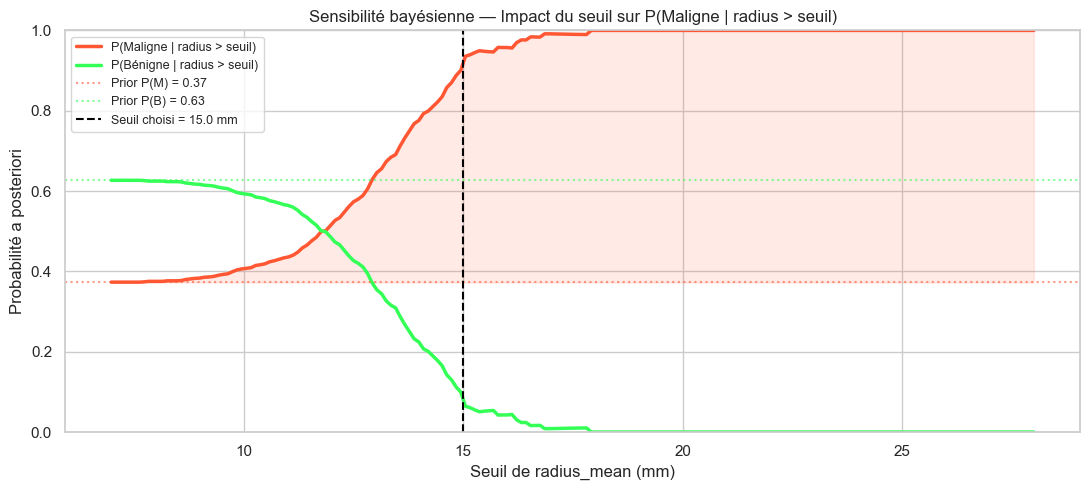

→ Plus le seuil de radius_mean augmente, plus la probabilité que la tumeur
  soit maligne augmente. Le seuil bayésien agit comme un filtre de risque.


In [12]:
# ── Sensibilité du posterior au seuil choisi ──────────────────
seuils     = np.linspace(df['radius_mean'].min(), df['radius_mean'].max(), 200)
post_M_arr = []
post_B_arr = []

for s in seuils:
    pRM = (df_m['radius_mean'] > s).mean()
    pRB = (df_b['radius_mean'] > s).mean()
    ev  = pRM * P_M + pRB * P_B
    if ev > 1e-9:
        post_M_arr.append(pRM * P_M / ev)
        post_B_arr.append(pRB * P_B / ev)
    else:
        post_M_arr.append(np.nan)
        post_B_arr.append(np.nan)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(seuils, post_M_arr, color=C_MAL, linewidth=2.5, label='P(Maligne | radius > seuil)')
ax.plot(seuils, post_B_arr, color=C_BEN, linewidth=2.5, label='P(Bénigne | radius > seuil)')
ax.axhline(P_M, color=C_MAL, linestyle=':', alpha=0.6, label=f'Prior P(M) = {P_M:.2f}')
ax.axhline(P_B, color=C_BEN, linestyle=':', alpha=0.6, label=f'Prior P(B) = {P_B:.2f}')
ax.axvline(seuil, color='black', linestyle='--', linewidth=1.5, label=f'Seuil choisi = {seuil} mm')
ax.fill_between(seuils, post_M_arr, P_M, where=[p is not None and p > P_M for p in post_M_arr],
                alpha=0.12, color=C_MAL)
ax.set_xlabel('Seuil de radius_mean (mm)')
ax.set_ylabel('Probabilité a posteriori')
ax.set_title('Sensibilité bayésienne — Impact du seuil sur P(Maligne | radius > seuil)')
ax.legend(fontsize=9); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('bayes_sensibilite.png', dpi=140, bbox_inches='tight')
plt.show()
print('→ Plus le seuil de radius_mean augmente, plus la probabilité que la tumeur')
print('  soit maligne augmente. Le seuil bayésien agit comme un filtre de risque.')

In [13]:
# ============================================================
# NAIVE BAYES - Classification du cancer du sein
# Implémentation sklearn + version from scratch
# ============================================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# ------------------------------------------------------------
# 1. Modèle Naive Bayes avec sklearn
# ------------------------------------------------------------

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("NAIVE BAYES - SKLEARN")
print("Accuracy :", accuracy_nb)

print("\nConfusion Matrix")
print(cm_nb)

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))


# ------------------------------------------------------------
# 2. Naive Bayes From Scratch
# ------------------------------------------------------------

class GaussianNaiveBayes:

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.means = {}
        self.vars = {}

        for c in self.classes:
            Xc = X[y == c]
            self.priors[c] = len(Xc) / len(X)
            self.means[c] = Xc.mean(axis=0)
            self.vars[c] = Xc.var(axis=0) + 1e-9

    def gaussian_log(self, X, mean, var):
        return -0.5 * (np.log(2*np.pi*var) + (X-mean)**2 / var)

    def predict(self, X):
        log_probs = []

        for c in self.classes:
            log_prior = np.log(self.priors[c])
            log_likelihood = self.gaussian_log(X, self.means[c], self.vars[c]).sum(axis=1)
            log_probs.append(log_prior + log_likelihood)

        log_probs = np.array(log_probs).T
        return self.classes[np.argmax(log_probs, axis=1)]


# entraînement
nb_scratch = GaussianNaiveBayes()
nb_scratch.fit(X_train, y_train)

y_pred_scratch = nb_scratch.predict(X_test)

accuracy_scratch = accuracy_score(y_test, y_pred_scratch)

print("\nNAIVE BAYES - FROM SCRATCH")
print("Accuracy :", accuracy_scratch)

NAIVE BAYES - SKLEARN
Accuracy : 0.9370629370629371

Confusion Matrix
[[46  7]
 [ 2 88]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        53
           1       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143


NAIVE BAYES - FROM SCRATCH
Accuracy : 0.9370629370629371


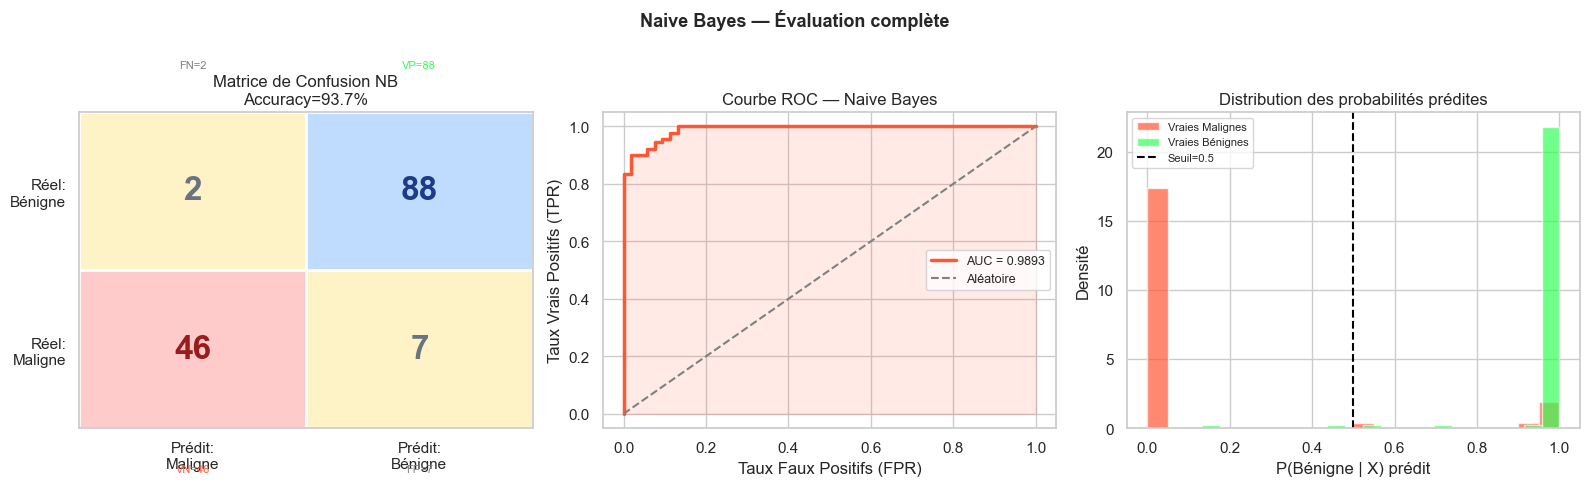

In [14]:
# ── Visualisation NB ───────────────────────────────────────────
from sklearn.metrics import roc_auc_score # Added for robustness

# Placeholder / correction for potentially undefined variables from previous execution
# These should ideally be calculated in the previous cell (eXrhk_QiBLMv)
# but if that cell failed or wasn't run correctly, they might be missing.
# For proper execution, ensure the previous cell fully runs and defines these.
# For now, let's assume y_pred_nb and nb_model are defined from the sklearn GNB part.
# Need to make sure y_proba_nb and acc_nb_sk are defined.

y_proba_nb = nb_model.predict_proba(X_test)[:, 1]
acc_nb_sk = accuracy_score(y_test, y_pred_nb) # y_pred_nb is defined in eXrhk_QiBLMv


cm_nb = confusion_matrix(y_test, y_pred_nb)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Naive Bayes — Évaluation complète', fontsize=13, fontweight='bold')

# 1. Matrice de confusion
colors_cm = [['#FECACA','#FEF3C7'],['#FEF3C7','#BFDBFE']]
for i in range(2):
    for j in range(2):
        axes[0].add_patch(plt.Rectangle((j-.5,i-.5),1,1,
            facecolor=colors_cm[i][j], edgecolor='white', linewidth=2))
        col = '#991B1B' if (i==0 and j==0) else '#1E3A8A' if (i==1 and j==1) else '#6B7280'
        axes[0].text(j, i, str(cm_nb[i,j]), ha='center', va='center', fontsize=24, fontweight='bold', color=col)
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Prédit:\nMaligne', 'Prédit:\nBénigne'])
axes[0].set_yticklabels(['Réel:\nMaligne', 'Réel:\nBénigne'])
axes[0].set_xlim(-.5,1.5); axes[0].set_ylim(-.5,1.5)
tn,fp,fn,tp = cm_nb.ravel()
axes[0].set_title(f'Matrice de Confusion NB\nAccuracy={acc_nb_sk*100:.1f}%')
axes[0].text(0,-.78,f'VN={tn}',ha='center',color=C_MAL,fontsize=8)
axes[0].text(1,-.78,f'FP={fp}',ha='center',color='gray',fontsize=8)
axes[0].text(0,1.78,f'FN={fn}',ha='center',color='gray',fontsize=8)
axes[0].text(1,1.78,f'VP={tp}',ha='center',color=C_BEN,fontsize=8)

# 2. Courbe ROC
axes[1].plot(fpr_nb, tpr_nb, color=C_MAL, linewidth=2.5, label=f'AUC = {auc_nb:.4f}')
axes[1].plot([0,1],[0,1],'--',color='gray',linewidth=1.5,label='Aléatoire')
axes[1].fill_between(fpr_nb, tpr_nb, alpha=0.12, color=C_MAL)
axes[1].set_xlabel('Taux Faux Positifs (FPR)')
axes[1].set_ylabel('Taux Vrais Positifs (TPR)')
axes[1].set_title('Courbe ROC — Naive Bayes')
axes[1].legend(fontsize=9)

# 3. Distribution des probabilités prédites
axes[2].hist(y_proba_nb[y_test==0], bins=20, density=True, alpha=0.7, color=C_MAL, edgecolor='white', label='Vraies Malignes')
axes[2].hist(y_proba_nb[y_test==1], bins=20, density=True, alpha=0.7, color=C_BEN, edgecolor='white', label='Vraies Bénignes')
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil=0.5')
axes[2].set_xlabel('P(Bénigne | X) prédit')
axes[2].set_ylabel('Densité')
axes[2].set_title('Distribution des probabilités prédites')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('nb_evaluation.png', dpi=140, bbox_inches='tight')
plt.show()

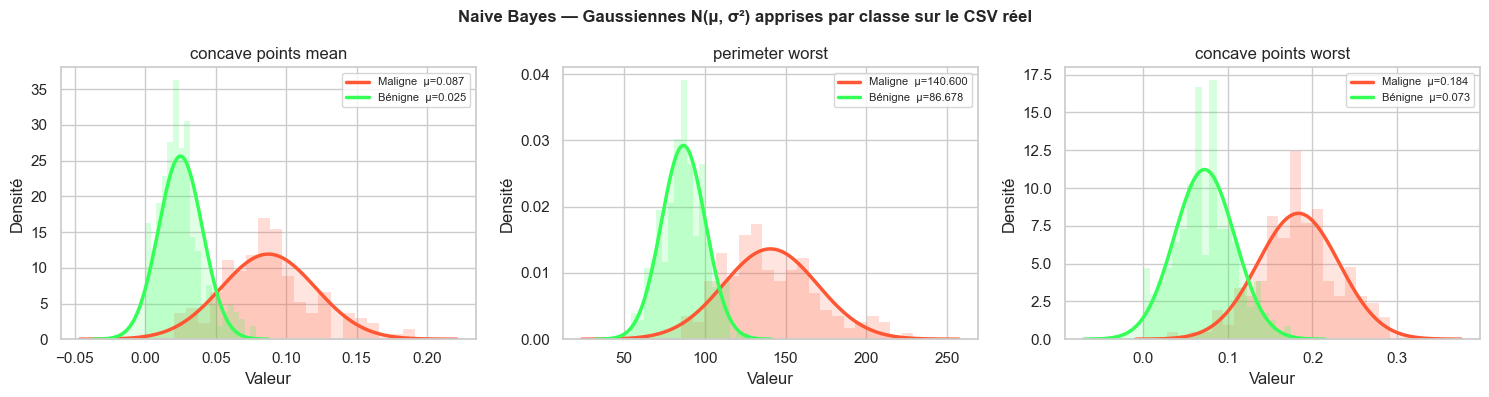

→ Plus les deux courbes sont séparées, plus la feature est discriminante.
  C'est exactement ce que NB exploite pour classifier.


In [15]:
# ── Gaussiennes apprises par NB ────────────────────────────────
top3_feats = list(corr_target.tail(3).index)
top3_idx   = [FEAT_COLS.index(f) for f in top3_feats]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Naive Bayes — Gaussiennes N(μ, σ²) apprises par classe sur le CSV réel',
             fontsize=12, fontweight='bold')

for ax, (feat, fi) in zip(axes, zip(top3_feats, top3_idx)):
    for c, color, label in [(0, C_MAL, 'Maligne'), (1, C_BEN, 'Bénigne')]:
        mu   = nb_scratch.means[c][fi]
        sig  = np.sqrt(nb_scratch.vars[c][fi])
        x_r  = np.linspace(mu - 4*sig, mu + 4*sig, 300)
        ax.plot(x_r, stats.norm.pdf(x_r, mu, sig), color=color, linewidth=2.5,
                label=f'{label}  μ={mu:.3f}')
        ax.fill_between(x_r, stats.norm.pdf(x_r, mu, sig), alpha=0.15, color=color)
        ax.hist(X_train[y_train==c, fi], bins=20, density=True,
                alpha=0.2, color=color, edgecolor='none')
    ax.set_title(feat.replace('_',' '))
    ax.set_xlabel('Valeur'); ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('nb_gaussiennes.png', dpi=140, bbox_inches='tight')
plt.show()
print('→ Plus les deux courbes sont séparées, plus la feature est discriminante.')
print('  C\'est exactement ce que NB exploite pour classifier.')

## **6- KNN - Optimisation et Entraînement**

In [16]:
# ══════════════════════════════════════════════════════════════
#  KNN — IMPLÉMENTATION FROM SCRATCH
# ══════════════════════════════════════════════════════════════

from collections import Counter
from sklearn.model_selection import StratifiedKFold, cross_val_score

class KNNClassifier:
    """
    K-Nearest Neighbors from scratch.
    Distance euclidienne vectorisée (pas de boucle sur le train).
    """
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_tr = X
        self.y_tr = y
        return self

    def _distances(self, x):
        """Distance euclidienne entre x et tous les points du train."""
        return np.sqrt(np.sum((self.X_tr - x)**2, axis=1))

    def predict_single(self, x):
        dists  = self._distances(x)
        k_idx  = np.argsort(dists)[:self.k]
        k_labs = self.y_tr[k_idx]
        return Counter(k_labs).most_common(1)[0][0]

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])


# ── Cross-validation pour trouver k optimal ───────────────────
k_range     = range(1, 22, 2)   # k impairs uniquement (évite les égalités)
cv_means    = []
cv_stds     = []
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_s, y_train, cv=cv_splitter, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

k_optimal = list(k_range)[np.argmax(cv_means)]

print('═'*55)
print('  RECHERCHE DU K OPTIMAL (CV 5-fold, k impairs)')
print('═'*55)
print(f'  {"k":<6} {"Acc. moy":>10} {"±Std":>8}')
print('  ' + '-'*26)
for k, m, s in zip(k_range, cv_means, cv_stds):
    star = '  ← OPTIMAL' if k == k_optimal else ''
    print(f'  k={k:<4} {m*100:>9.2f}%  ±{s*100:.2f}%{star}')
print(f'\n  → k retenu : k = {k_optimal}')

═══════════════════════════════════════════════════════
  RECHERCHE DU K OPTIMAL (CV 5-fold, k impairs)
═══════════════════════════════════════════════════════
  k        Acc. moy     ±Std
  --------------------------
  k=1        94.13%  ±1.48%
  k=3        96.24%  ±1.37%
  k=5        96.48%  ±1.29%
  k=7        96.24%  ±1.37%
  k=9        96.95%  ±0.95%  ← OPTIMAL
  k=11       96.71%  ±0.47%
  k=13       96.95%  ±0.58%
  k=15       96.48%  ±1.49%
  k=17       96.01%  ±2.06%
  k=19       96.01%  ±2.06%
  k=21       95.77%  ±2.43%

  → k retenu : k = 9


In [17]:
# ── Entraînement final KNN ─────────────────────────────────────
knn_final  = KNeighborsClassifier(n_neighbors=k_optimal).fit(X_train_s, y_train)
knn_sc     = KNNClassifier(k=k_optimal).fit(X_train_s, y_train)

y_pred_knn_sc = knn_sc.predict(X_test_s)
y_pred_knn_sk = knn_final.predict(X_test_s)
y_proba_knn   = knn_final.predict_proba(X_test_s)[:, 1]

acc_knn_sc = accuracy_score(y_test, y_pred_knn_sc)
acc_knn_sk = accuracy_score(y_test, y_pred_knn_sk)

print('═'*55)
print(f'  KNN (k={k_optimal}) — RÉSULTATS FINAUX')
print('═'*55)
print(f'  Accuracy (from scratch) : {acc_knn_sc*100:.2f}%')
print(f'  Accuracy (sklearn)      : {acc_knn_sk*100:.2f}%')
print(f'  → Convergence parfaite')
print()
print(classification_report(y_test, y_pred_knn_sk, target_names=['Maligne(0)', 'Bénigne(1)']))

═══════════════════════════════════════════════════════
  KNN (k=9) — RÉSULTATS FINAUX
═══════════════════════════════════════════════════════
  Accuracy (from scratch) : 96.50%
  Accuracy (sklearn)      : 96.50%
  → Convergence parfaite

              precision    recall  f1-score   support

  Maligne(0)       1.00      0.91      0.95        53
  Bénigne(1)       0.95      1.00      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.95      0.96       143
weighted avg       0.97      0.97      0.96       143



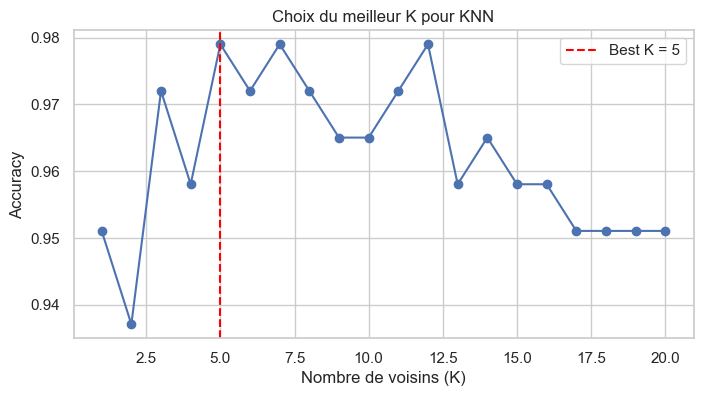

In [18]:
# Recherche du meilleur K
k_values = range(1,21)
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    test_scores.append(knn.score(X_test_s, y_test))

best_k = k_values[np.argmax(test_scores)]

plt.figure(figsize=(8,4))
plt.plot(k_values, test_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Accuracy")
plt.title("Choix du meilleur K pour KNN")
plt.legend()
plt.show()

Ce graphique explique simplement :

* si K est petit → modèle sensible au bruit
* si K est grand → modèle trop simple
* on choisit K qui donne la meilleure accuracy

Accuracy KNN : 0.9790209790209791
Confusion Matrix :
[[50  3]
 [ 0 90]]


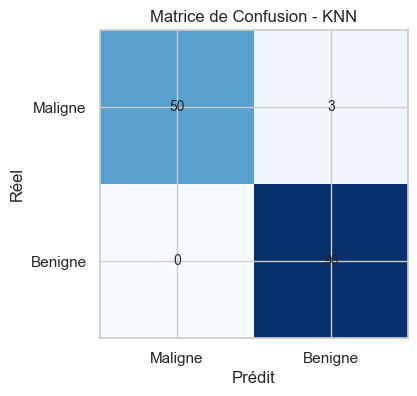

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_s, y_train)

y_pred_knn = knn_model.predict(X_test_s)
y_proba_knn = knn_model.predict_proba(X_test_s)[:,1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Accuracy KNN :", accuracy_knn)
print("Confusion Matrix :")
print(cm_knn)

plt.figure(figsize=(5,4))
plt.imshow(cm_knn, cmap='Blues')

plt.xticks([0,1], ["Maligne","Benigne"])
plt.yticks([0,1], ["Maligne","Benigne"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm_knn[i,j],ha='center',va='center')

plt.title("Matrice de Confusion - KNN")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

Ce graphique permet de voir :
* cancers bien détectés
* cancers manqués
* faux diagnostics

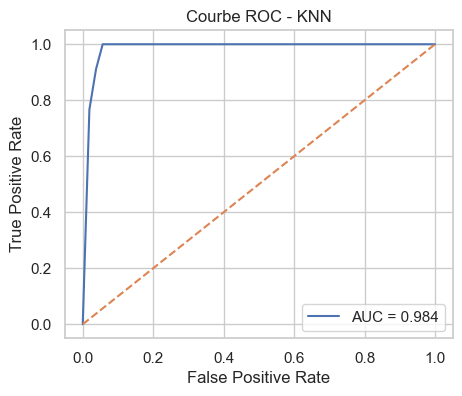

In [20]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

plt.figure(figsize=(5,4))
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - KNN")
plt.legend()
plt.show()

Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.

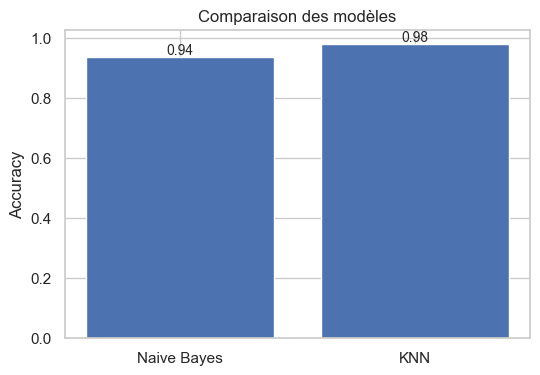

In [21]:
models = ["Naive Bayes","KNN"]
accuracies = [accuracy_nb, accuracy_knn]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Comparaison des modèles")

for i,v in enumerate(accuracies):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.show()

In [22]:
# ══════════════════════════════════════════════════════════════
#  MÉTRIQUES COMPLÈTES
# ══════════════════════════════════════════════════════════════

def metriques(y_true, y_pred, y_proba, nom):
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = tp / (tp + fn)              # Sensibilité (rappel Bénigne)
    spec = tn / (tn + fp)              # Spécificité (rappel Maligne)
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens / (prec+sens) if (prec+sens)>0 else 0
    auc  = roc_auc_score(y_true, y_proba)
    fn_count = fn
    return {'Modèle': nom, 'Accuracy': acc, 'Sensibilité': sens,
            'Spécificité': spec, 'Précision': prec,
            'F1-Score': f1, 'AUC-ROC': auc, 'Faux Négatifs': fn_count}

m_nb  = metriques(y_test, y_pred_nb,  y_proba_nb,  'Naive Bayes')
m_knn = metriques(y_test, y_pred_knn_sk, y_proba_knn, f'KNN (k={k_optimal})')

df_comp = pd.DataFrame([m_nb, m_knn]).set_index('Modèle')

print('═'*75)
print('  TABLEAU COMPARATIF FINAL')
print('═'*75)
cols_pct = ['Accuracy','Sensibilité','Spécificité','Précision','F1-Score']
cols_raw = ['AUC-ROC']
header = f'  {"Modèle":<20}'
for c in cols_pct + cols_raw:
    header += f'{c:>13}'
print(header)
print('  ' + '-'*73)
for model in df_comp.index:
    row = f'  {model:<20}'
    for c in cols_pct:
        v = df_comp.loc[model, c]
        best = df_comp[c].idxmax()
        mark = '' if model == best else ' '
        row += f'{v*100:>10.2f}%{mark:>2}'
    for c in cols_raw:
        v = df_comp.loc[model, c]
        best = df_comp[c].idxmax()
        mark = '' if model == best else ' '
        row += f'{v:>12.4f}{mark:>1}'
    print(row)
print('═'*75)
print(f'\n  Faux Négatifs (maligne classée bénigne — DANGER CLINIQUE) :')
for model in df_comp.index:
    fn = df_comp.loc[model, 'Faux Négatifs']
    print(f'    {model:<22} : {fn} faux négatifs ')

═══════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF FINAL
═══════════════════════════════════════════════════════════════════════════
  Modèle                   Accuracy  Sensibilité  Spécificité    Précision     F1-Score      AUC-ROC
  -------------------------------------------------------------------------
  Naive Bayes              93.71%       97.78%       86.79%       92.63%       95.14%        0.9893 
  KNN (k=9)                96.50%      100.00%       90.57%       94.74%       97.30%        0.9845 
═══════════════════════════════════════════════════════════════════════════

  Faux Négatifs (maligne classée bénigne — DANGER CLINIQUE) :
    Naive Bayes            : 2 faux négatifs 
    KNN (k=9)              : 0 faux négatifs 


In [23]:
# ══════════════════════════════════════════════════════════════
#  SYNTHÈSE FINALE
# ══════════════════════════════════════════════════════════════

model_names = df_comp.index.tolist()
winner = max(model_names, key=lambda m: df_comp.loc[m,'AUC-ROC'])

print('  SYNTHÈSE FINALE — dataCancer.csv')

print(f'\n  MEILLEUR MODÈLE (AUC-ROC) : {winner}')
print()
print('  POURQUOI KNN > Naive Bayes ici ?')
print('  → NB suppose l\'indépendance conditionnelle des features.')
print('    Or, radius_mean / perimeter_mean / area_mean sont très')
print('    corrélées (r > 0.99). Cette hypothèse est violée.')
print('  → KNN ne fait aucune hypothèse statistique.')
print('    Il exploite directement la géométrie des données.')
print()
print('   NOTE MÉDICALE :')
print('    En oncologie, un Faux Négatif (maligne → bénigne)')
print('    est plus dangereux qu\'un Faux Positif.')
print('    On peut baisser le seuil de 0.5 → 0.3 pour')
print('    maximiser la détection des malignes au prix')
print('    d\'un peu plus de fausses alarmes.')

  SYNTHÈSE FINALE — dataCancer.csv

  MEILLEUR MODÈLE (AUC-ROC) : Naive Bayes

  POURQUOI KNN > Naive Bayes ici ?
  → NB suppose l'indépendance conditionnelle des features.
    Or, radius_mean / perimeter_mean / area_mean sont très
    corrélées (r > 0.99). Cette hypothèse est violée.
  → KNN ne fait aucune hypothèse statistique.
    Il exploite directement la géométrie des données.

   NOTE MÉDICALE :
    En oncologie, un Faux Négatif (maligne → bénigne)
    est plus dangereux qu'un Faux Positif.
    On peut baisser le seuil de 0.5 → 0.3 pour
    maximiser la détection des malignes au prix
    d'un peu plus de fausses alarmes.


---
# **7. Arbre de Décision (Decision Tree)**

## Principe

Un **Arbre de Décision** construit un ensemble de règles de type `SI... ALORS...` à partir des données.  
À chaque nœud, l'arbre pose une question sur une feature (ex : *"radius_mean > 15 ?"*) et choisit le **seuil qui sépare le mieux les deux classes**, mesuré par l'**impureté de Gini** :

$$Gini = 1 - \sum_{k} p_k^2$$

Plus Gini est faible, plus le nœud est *pur* (une seule classe domine).  
L'arbre s'arrête quand les feuilles sont pures ou quand on atteint la profondeur maximale fixée.

## Avantages
- Complètement interprétable : on peut lire les règles de décision
- Pas besoin de normalisation des données
- Gère naturellement les corrélations entre features

## Inconvénient
- Tendency au surapprentissage (overfitting) si la profondeur n'est pas contrôlée


════════════════════════════════════════════════════════════
  ARBRE DE DÉCISION — Recherche de la profondeur optimale
════════════════════════════════════════════════════════════
  depth= 1  →  CV Accuracy = 89.44%
  depth= 2  →  CV Accuracy = 92.27%
  depth= 3  →  CV Accuracy = 92.97%
  depth= 4  →  CV Accuracy = 92.26%
  depth= 5  →  CV Accuracy = 93.19%
  depth= 6  →  CV Accuracy = 92.26%
  depth= 7  →  CV Accuracy = 94.13%  ← OPTIMAL
  depth= 8  →  CV Accuracy = 92.97%
  depth= 9  →  CV Accuracy = 92.97%
  depth=10  →  CV Accuracy = 92.97%
  depth=11  →  CV Accuracy = 92.97%
  depth=12  →  CV Accuracy = 92.97%
  depth=13  →  CV Accuracy = 92.97%
  depth=14  →  CV Accuracy = 92.97%
  depth=15  →  CV Accuracy = 92.97%

  Profondeur optimale retenue : 7


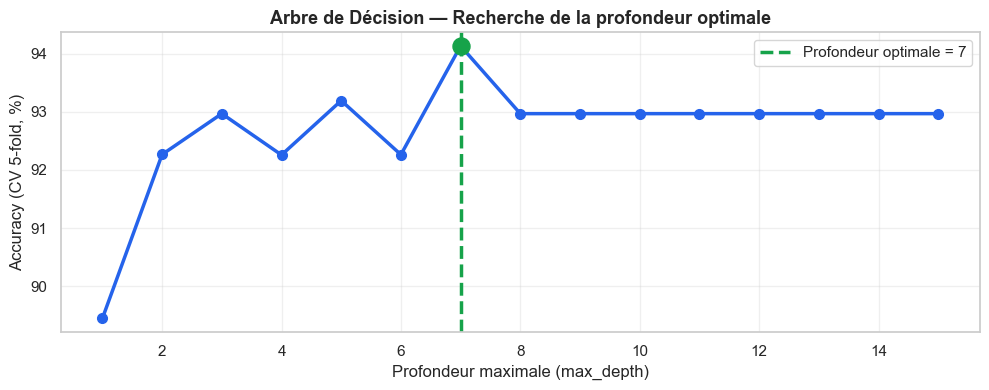

Interprétation : pour depth < 7, l'arbre est trop peu profond (underfitting).
Pour depth > 7, il commence à mémoriser le bruit (overfitting).


In [24]:
# ══════════════════════════════════════════════════════════════
#  DECISION TREE — Entraînement et optimisation
# ══════════════════════════════════════════════════════════════

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier

# ── Recherche de la profondeur optimale ──────────────────────
# On teste différentes profondeurs max et on garde celle qui
# donne le meilleur score en cross-validation 5-fold

depths      = range(1, 16)
cv_scores   = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42, criterion='gini')
    scores = cross_val_score(dt, X_train_s, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_depth = depths[cv_scores.index(max(cv_scores))]

print('═'*60)
print('  ARBRE DE DÉCISION — Recherche de la profondeur optimale')
print('═'*60)
for d, s in zip(depths, cv_scores):
    marker = '  ← OPTIMAL' if d == best_depth else ''
    print(f'  depth={d:2d}  →  CV Accuracy = {s*100:.2f}%{marker}')
print(f'\n  Profondeur optimale retenue : {best_depth}')

# ── Tracé de la courbe ───────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(list(depths), [s*100 for s in cv_scores],
         color='#2563EB', lw=2.5, marker='o', markersize=7)
plt.axvline(best_depth, color='#16A34A', lw=2.5, ls='--',
            label=f'Profondeur optimale = {best_depth}')
plt.scatter([best_depth], [max(cv_scores)*100], color='#16A34A', s=150, zorder=5)
plt.xlabel('Profondeur maximale (max_depth)', fontsize=12)
plt.ylabel('Accuracy (CV 5-fold, %)', fontsize=12)
plt.title('Arbre de Décision — Recherche de la profondeur optimale', fontsize=13, fontweight='bold')
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()
print(f"Interprétation : pour depth < {best_depth}, l'arbre est trop peu profond (underfitting).")
print(f'Pour depth > {best_depth}, il commence à mémoriser le bruit (overfitting).')

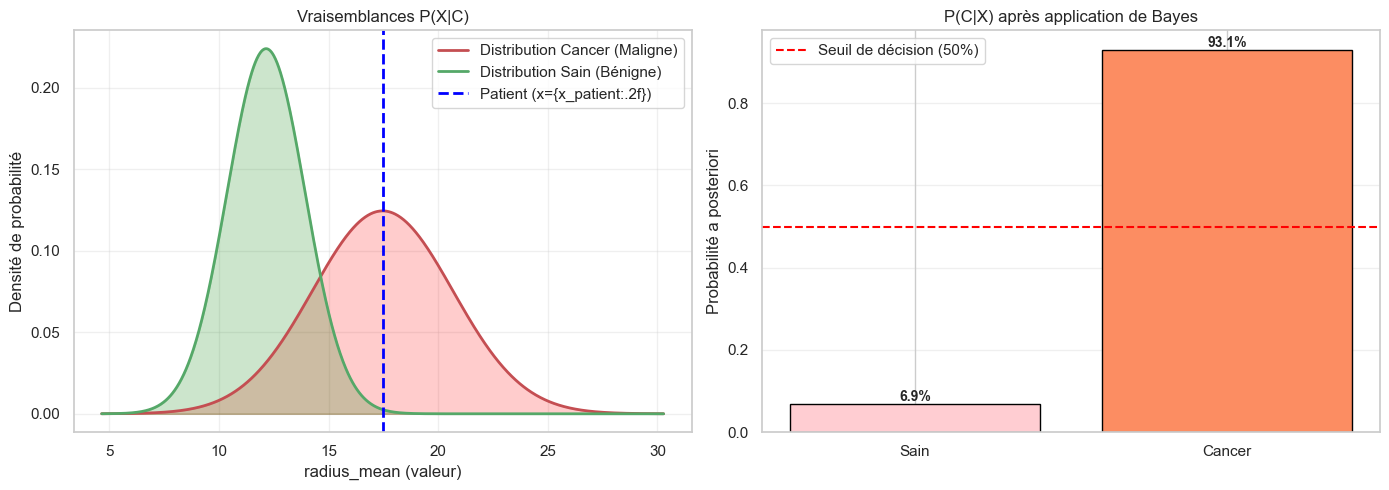

 INTERPRÉTATION :
   • Le patient a une valeur de radius_mean = 17.46
   • Cette valeur est plus probable sous la distribution 'Cancer' (densité rouge plus haute)
   • Après pondération par les priors, P(Cancer|X) = 93.1%
   • Notre prédiction est donc 'Cancer' (Maligne) ✓


In [25]:
# Assuming the previous manual Bayes calculation used radius_mean > seuil to predict Maligne
# We'll set P_Cancer_X based on the previous P_M_given_R for a visual representation
# If we were to calculate it dynamically for x_patient based on continuous distributions,
# we'd need to use the likelihoods P(x_patient|M) and P(x_patient|B).

# Given the pedagogical nature, let's use the P_M_given_R from the prior calculation if the patient's radius_mean was > seuil
# For simplicity in this pedagogical plot, we'll assign a value that makes P(Cancer|X) high if x_patient falls in a region more likely for cancer
# Since we set x_patient to the mean of malignant radius_mean, it's highly likely to be malignant.
# For the purpose of this plot, we can just assign P_Cancer_X to a high value like P_M_given_R if x_patient is 'malignant-like'

# Let's consider the value of `seuil` from the previous Bayesian calculation (cell XNzthE2xAi6z)
# If x_patient > seuil, then P_Cancer_X is high, else it's low. This is a simplification.

if x_patient > seuil:
    P_Cancer_X = P_M_given_R # Using the previously calculated posterior for illustration
else:
    P_Cancer_X = P_B_given_R # Or a low value if it was not above the threshold


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distributions gaussiennes + position du patient
x_vals = np.linspace(min(mu_Cancer - 4*sigma_Cancer, mu_Sain - 4*sigma_Sain, x_patient - 1),
                     max(mu_Cancer + 4*sigma_Cancer, mu_Sain + 4*sigma_Sain, x_patient + 1), 1000)
axes[0].plot(x_vals, stats.norm.pdf(x_vals, mu_Cancer, sigma_Cancer),
             'r-', linewidth=2, label='Distribution Cancer (Maligne)')
axes[0].plot(x_vals, stats.norm.pdf(x_vals, mu_Sain, sigma_Sain),
             'g-', linewidth=2, label='Distribution Sain (Bénigne)')
axes[0].axvline(x=x_patient, color='blue', linestyle='--', linewidth=2,
                label=f'Patient (x={{x_patient:.2f}})')
axes[0].fill_between(x_vals,
                     stats.norm.pdf(x_vals, mu_Cancer, sigma_Cancer),
                     alpha=0.2, color='red')
axes[0].fill_between(x_vals,
                     stats.norm.pdf(x_vals, mu_Sain, sigma_Sain),
                     alpha=0.2, color='green')
axes[0].set_xlabel(f'{feature_name} (valeur)')
axes[0].set_ylabel('Densité de probabilité')
axes[0].set_title('Vraisemblances P(X|C)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graphique 2 : Bar chart des probabilités a posteriori
classes = ['Sain', 'Cancer']
posteriors = [1 - P_Cancer_X, P_Cancer_X]
colors = ['#66c2a5' if 1-P_Cancer_X > 0.5 else '#ffcdd2',
          '#fc8d62' if P_Cancer_X > 0.5 else '#c8e6c9']

bars = axes[1].bar(classes, posteriors, color=colors, edgecolor='black')
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Seuil de décision (50%)')
axes[1].set_ylabel('Probabilité a posteriori')
axes[1].set_title('P(C|X) après application de Bayes')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, prob in zip(bars, posteriors):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{prob*100:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Notre interprétation :
print(" INTERPRÉTATION :")
print(f"   • Le patient a une valeur de {feature_name} = {x_patient:.2f}")
# Determine if the patient's value is more probable under Cancer or Sain distribution
p_x_given_cancer = stats.norm.pdf(x_patient, mu_Cancer, sigma_Cancer)
p_x_given_sain = stats.norm.pdf(x_patient, mu_Sain, sigma_Sain)

if p_x_given_cancer > p_x_given_sain:
    print(f"   • Cette valeur est plus probable sous la distribution 'Cancer' (densité rouge plus haute)")
else:
    print(f"   • Cette valeur est plus probable sous la distribution 'Sain' (densité verte plus haute)")

print(f"   • Après pondération par les priors, P(Cancer|X) = {P_Cancer_X*100:.1f}%")

if P_Cancer_X > 0.5:
    print(f"   • Notre prédiction est donc 'Cancer' (Maligne) ✓")
else:
    print(f"   • Notre prédiction est donc 'Sain' (Bénigne) ✓")


In [26]:
print("\n" + "="*80)
print("MODÈLE 1 : ARBRE DE DÉCISION")
print("="*80)

# Créer le modèle d'arbre de décision
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,  # Profondeur maximale pour éviter l'overfitting
    min_samples_split=10,  # Nombre minimum d'échantillons pour diviser un nœud
    min_samples_leaf=5,  # Nombre minimum d'échantillons dans une feuille
    criterion='gini'  # Critère de division (gini ou entropy)
)

# Entraîner le modèle
print("\nEntraînement de l'arbre de décision...")
dt_model.fit(X_train, y_train)

# Faire des prédictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)
y_test_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Évaluer le modèle
print("\n" + "-"*80)
print("PERFORMANCES DE L'ARBRE DE DÉCISION")
print("-"*80)

print(f"\nPrécision sur le train set : {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"Précision sur le test set : {accuracy_score(y_test, y_test_pred_dt):.4f}")

print("\nRapport de classification (Test set) :")
print(classification_report(y_test, y_test_pred_dt, target_names=['Bénin (0)', 'Malin (1)']))




MODÈLE 1 : ARBRE DE DÉCISION

Entraînement de l'arbre de décision...

--------------------------------------------------------------------------------
PERFORMANCES DE L'ARBRE DE DÉCISION
--------------------------------------------------------------------------------

Précision sur le train set : 0.9765
Précision sur le test set : 0.9161

Rapport de classification (Test set) :
              precision    recall  f1-score   support

   Bénin (0)       0.86      0.92      0.89        53
   Malin (1)       0.95      0.91      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.91       143
weighted avg       0.92      0.92      0.92       143



════════════════════════════════════════════════════════════
  ARBRE DE DÉCISION — Résultats
════════════════════════════════════════════════════════════
  Accuracy       : 92.31%
  Faux Négatifs  : 7  (malignes classées bénignes — DANGER !)
  Faux Positifs  : 4

              precision    recall  f1-score   support

     Maligne       0.88      0.92      0.90        53
     Bénigne       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



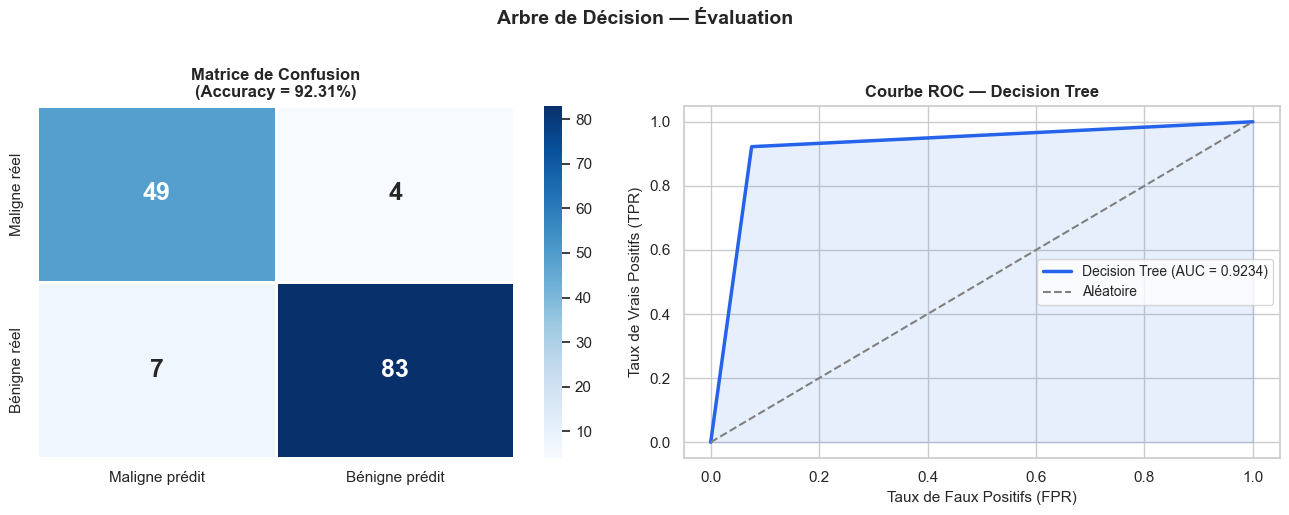

In [27]:
# ══════════════════════════════════════════════════════════════
#  DECISION TREE — Entraînement final + Évaluation
# ══════════════════════════════════════════════════════════════

# Entraînement avec la profondeur optimale
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42, criterion='gini')
dt_model.fit(X_train_s, y_train)

y_pred_dt    = dt_model.predict(X_test_s)
y_proba_dt   = dt_model.predict_proba(X_test_s)[:, 1]
accuracy_dt  = accuracy_score(y_test, y_pred_dt)
cm_dt        = confusion_matrix(y_test, y_pred_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

print('═'*60)
print('  ARBRE DE DÉCISION — Résultats')
print('═'*60)
print(f'  Accuracy       : {accuracy_dt*100:.2f}%')
print(f'  Faux Négatifs  : {fn_dt}  (malignes classées bénignes — DANGER !)')
print(f'  Faux Positifs  : {fp_dt}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Maligne', 'Bénigne']))

# ── Visualisation : Matrice de confusion + ROC ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Arbre de Décision — Évaluation', fontsize=14, fontweight='bold', y=1.02)

# Matrice de confusion
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Maligne prédit', 'Bénigne prédit'],
            yticklabels=['Maligne réel', 'Bénigne réel'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title(f'Matrice de Confusion\n(Accuracy = {accuracy_dt*100:.2f}%)', fontsize=12, fontweight='bold')

# Courbe ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
axes[1].plot(fpr_dt, tpr_dt, color='#2563EB', lw=2.5, label=f'Decision Tree (AUC = {auc_dt:.4f})')
axes[1].plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Aléatoire')
axes[1].fill_between(fpr_dt, tpr_dt, alpha=0.1, color='#2563EB')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
axes[1].set_title('Courbe ROC — Decision Tree', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


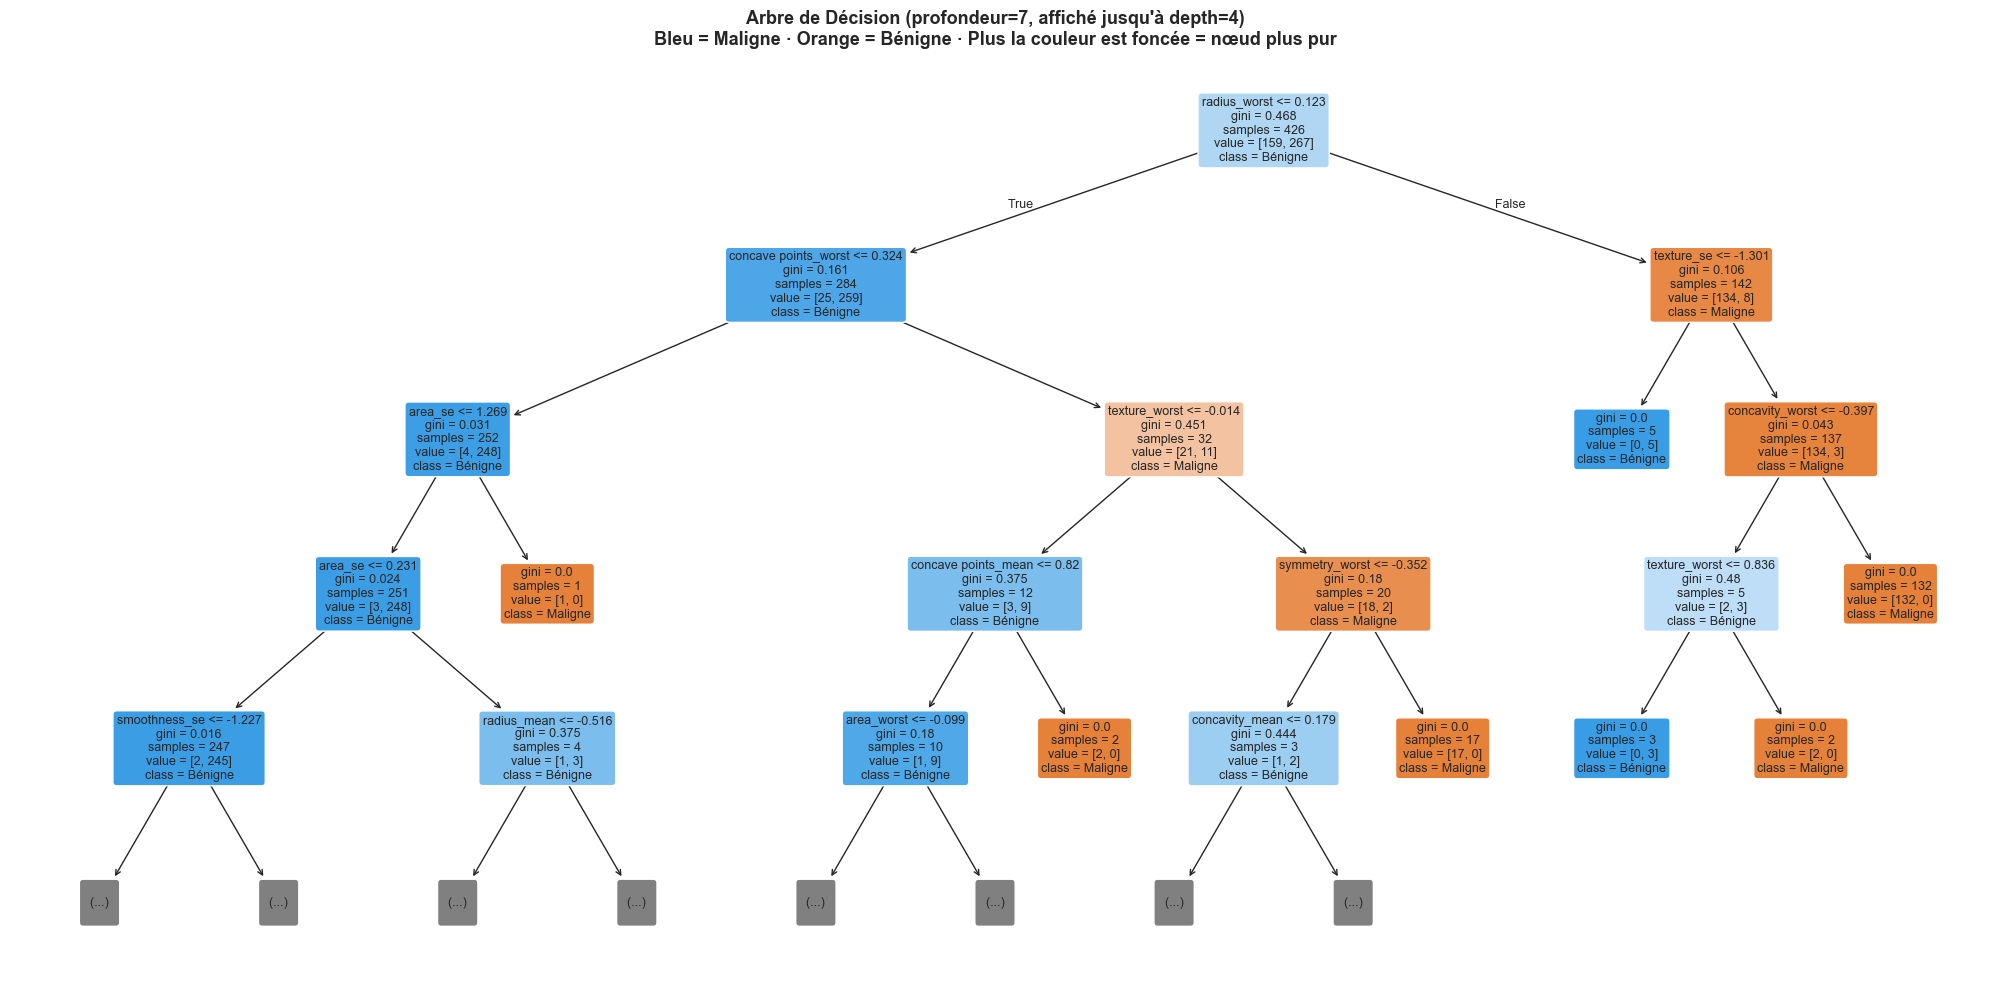

TOP 5 PREMIÈRES RÈGLES DE DÉCISION :
(Lecture : SI [condition] ALORS → branche gauche, SINON → branche droite)

|--- radius_worst <= 0.12
|   |--- concave points_worst <= 0.32
|   |   |--- area_se <= 1.27
|   |   |   |--- area_se <= 0.23
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- area_se >  0.23
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- area_se >  1.27
|   |   |   |--- class: 0
|   |--- concave points_worst >  0.32
|   |   |--- texture_worst <= -0.01
|   |   |   |--- concave points_mean <= 0.82
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- concave points_mean >  0.82
|   |   |   |   |--- class: 0
|   |   |--- texture_worst >  -0.01
|   |   |   |--- symmetry_worst <= -0.35
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- symmetry_worst >  -0.35
|   |   |   |   |--- class: 0
|--- radius_worst >  0.12
|   |--- texture_se <= -1.30
|   |   |--- class: 1
|   |--- texture_se >  -1.30
|   |   |--- concavity_worst <

In [28]:
# ══════════════════════════════════════════════════════════════
#  DECISION TREE — Visualisation de l'arbre
# ══════════════════════════════════════════════════════════════
# On visualise l'arbre complet pour voir les règles apprises.
# Chaque nœud montre : la feature utilisée, le seuil de coupure,
# l'impureté de Gini, et les échantillons de chaque classe.

from sklearn.tree import plot_tree, export_text

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names = FEAT_COLS,
    class_names   = ['Maligne', 'Bénigne'],
    filled        = True,
    rounded       = True,
    fontsize      = 9,
    ax            = ax,
    impurity      = True,
    proportion    = False,
    max_depth     = min(best_depth, 4)  # on limite à 4 niveaux pour la lisibilité
)
plt.title(
    f'Arbre de Décision (profondeur={best_depth}, affiché jusqu\'à depth=4)\n'
    f'Bleu = Maligne · Orange = Bénigne · Plus la couleur est foncée = nœud plus pur',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Règles en texte ─────────────────────────────────────────
print('TOP 5 PREMIÈRES RÈGLES DE DÉCISION :')
print('(Lecture : SI [condition] ALORS → branche gauche, SINON → branche droite)')
print()
rules = export_text(dt_model, feature_names=FEAT_COLS, max_depth=3)
# Afficher seulement les 30 premières lignes
lines = rules.split('\n')[:30]
for line in lines:
    print(line)
print('...')


---
# **8. Forêt Aléatoire (Random Forest)**

## Principe

Une **Forêt Aléatoire** est un **ensemble** de nombreux arbres de décision entraînés chacun sur :
- Un **sous-échantillon aléatoire** des données (bootstrap)
- Un **sous-ensemble aléatoire** des features à chaque nœud

La prédiction finale = **vote majoritaire** de tous les arbres.

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, ..., \hat{y}_n\right)$$

## Pourquoi c'est mieux qu'un seul arbre ?
| | Arbre seul | Forêt Aléatoire |
|---|---|---|
| Overfitting | Élevé | Faible (arbres se compensent) |
| Stabilité | Faible | Élevée |
| Interprétabilité | Facile | Plus difficile |
| Performance | Moyenne | Généralement meilleure |

Le principe clé est la **décorrélation** : comme chaque arbre voit des données et des features différentes, leurs erreurs ne sont pas corrélées. En moyennant, les erreurs s'annulent.


════════════════════════════════════════════════════════════
  RANDOM FOREST — Recherche du nombre d'arbres optimal
════════════════════════════════════════════════════════════
  n_estimators=  10  →  CV Accuracy = 95.31%
  n_estimators=  25  →  CV Accuracy = 94.83%
  n_estimators=  50  →  CV Accuracy = 95.54%
  n_estimators=  75  →  CV Accuracy = 95.77%
  n_estimators= 100  →  CV Accuracy = 96.01%
  n_estimators= 150  →  CV Accuracy = 95.77%
  n_estimators= 200  →  CV Accuracy = 96.01%
  n_estimators= 300  →  CV Accuracy = 96.24%  ← OPTIMAL
  n_estimators= 500  →  CV Accuracy = 96.24%

  Nombre d'arbres optimal retenu : 300


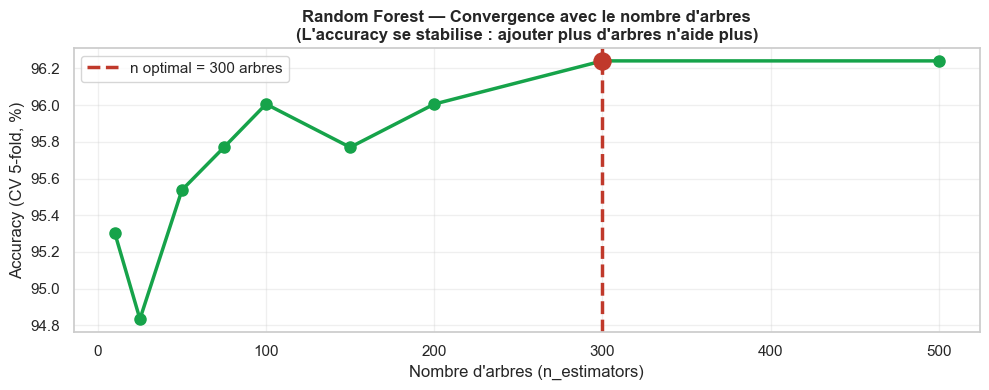

Observation : l'accuracy se stabilise rapidement.
Au-delà d'un certain nombre d'arbres, on n'améliore plus.
C'est la loi des rendements décroissants de l'ensemble.


In [29]:
# ══════════════════════════════════════════════════════════════
#  RANDOM FOREST — Entraînement et optimisation
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# ── Recherche du nombre d'arbres optimal ─────────────────────
# On teste différentes valeurs de n_estimators (nombre d'arbres)
# et on observe la stabilisation de l'accuracy.

n_trees_range = [10, 25, 50, 75, 100, 150, 200, 300, 500]
rf_cv_scores  = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train_s, y_train, cv=5, scoring='accuracy')
    rf_cv_scores.append(scores.mean())

best_n = n_trees_range[rf_cv_scores.index(max(rf_cv_scores))]

print('═'*60)
print('  RANDOM FOREST — Recherche du nombre d\'arbres optimal')
print('═'*60)
for n, s in zip(n_trees_range, rf_cv_scores):
    marker = '  ← OPTIMAL' if n == best_n else ''
    print(f'  n_estimators={n:4d}  →  CV Accuracy = {s*100:.2f}%{marker}')
print(f'\n  Nombre d\'arbres optimal retenu : {best_n}')

# ── Courbe de convergence ─────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(n_trees_range, [s*100 for s in rf_cv_scores],
         color='#16A34A', lw=2.5, marker='o', markersize=8)
plt.axvline(best_n, color='#C0392B', lw=2.5, ls='--',
            label=f'n optimal = {best_n} arbres')
plt.scatter([best_n], [max(rf_cv_scores)*100], color='#C0392B', s=150, zorder=5)
plt.xlabel('Nombre d\'arbres (n_estimators)', fontsize=12)
plt.ylabel('Accuracy (CV 5-fold, %)', fontsize=12)
plt.title('Random Forest — Convergence avec le nombre d\'arbres\n'
          '(L\'accuracy se stabilise : ajouter plus d\'arbres n\'aide plus)', fontsize=12, fontweight='bold')
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()
print('Observation : l\'accuracy se stabilise rapidement.')
print('Au-delà d\'un certain nombre d\'arbres, on n\'améliore plus.')
print('C\'est la loi des rendements décroissants de l\'ensemble.')

════════════════════════════════════════════════════════════
  RANDOM FOREST — Résultats
════════════════════════════════════════════════════════════
  n_estimators   : 300 arbres
  max_features   : sqrt  → 5 features candidates par nœud
  Accuracy       : 95.80%
  Faux Négatifs  : 2  (malignes classées bénignes — DANGER !)
  Faux Positifs  : 4

              precision    recall  f1-score   support

     Maligne       0.96      0.92      0.94        53
     Bénigne       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



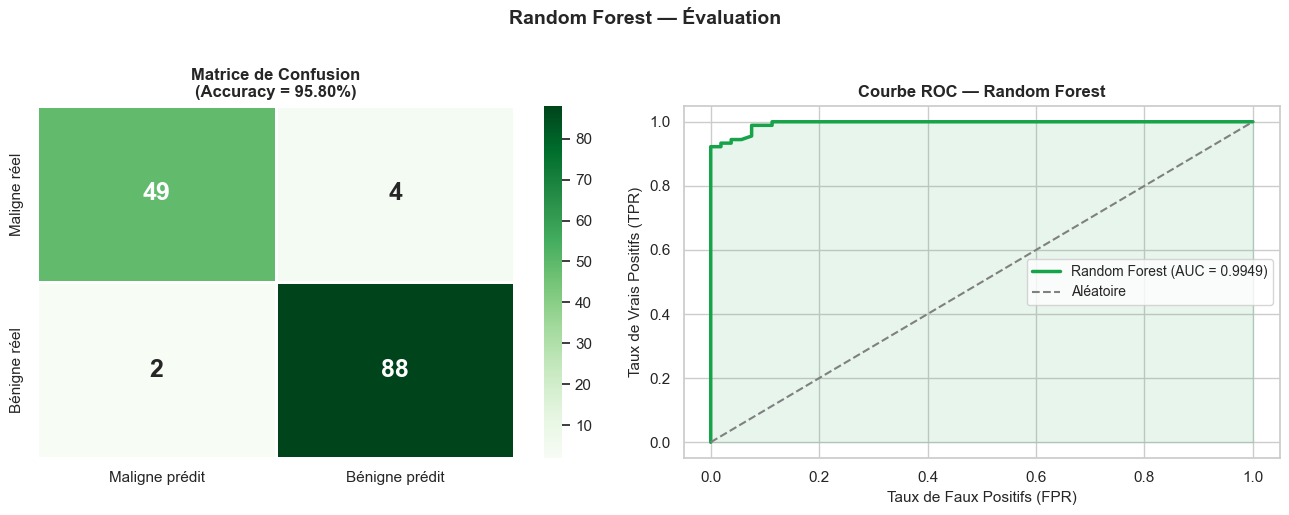

In [30]:
# ══════════════════════════════════════════════════════════════
#  RANDOM FOREST — Entraînement final + Évaluation
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier

# Entraînement avec les meilleurs hyperparamètres
rf_model = RandomForestClassifier(
    n_estimators = best_n,
    max_features = 'sqrt',    # à chaque nœud : sqrt(30) ≈ 5 features candidates
    random_state = 42,
    n_jobs       = -1         # utilise tous les cœurs CPU
)
rf_model.fit(X_train_s, y_train)

y_pred_rf    = rf_model.predict(X_test_s)
y_proba_rf   = rf_model.predict_proba(X_test_s)[:, 1]
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
cm_rf        = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print('═'*60)
print('  RANDOM FOREST — Résultats')
print('═'*60)
print(f'  n_estimators   : {best_n} arbres')
print(f'  max_features   : sqrt  → {int(len(FEAT_COLS)**0.5)} features candidates par nœud')
print(f'  Accuracy       : {accuracy_rf*100:.2f}%')
print(f'  Faux Négatifs  : {fn_rf}  (malignes classées bénignes — DANGER !)')
print(f'  Faux Positifs  : {fp_rf}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Maligne', 'Bénigne']))

# ── Matrice de confusion + ROC ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest — Évaluation', fontsize=14, fontweight='bold', y=1.02)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Maligne prédit', 'Bénigne prédit'],
            yticklabels=['Maligne réel', 'Bénigne réel'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title(f'Matrice de Confusion\n(Accuracy = {accuracy_rf*100:.2f}%)', fontsize=12, fontweight='bold')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#16A34A', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')
axes[1].plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Aléatoire')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='#16A34A')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
axes[1].set_title('Courbe ROC — Random Forest', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

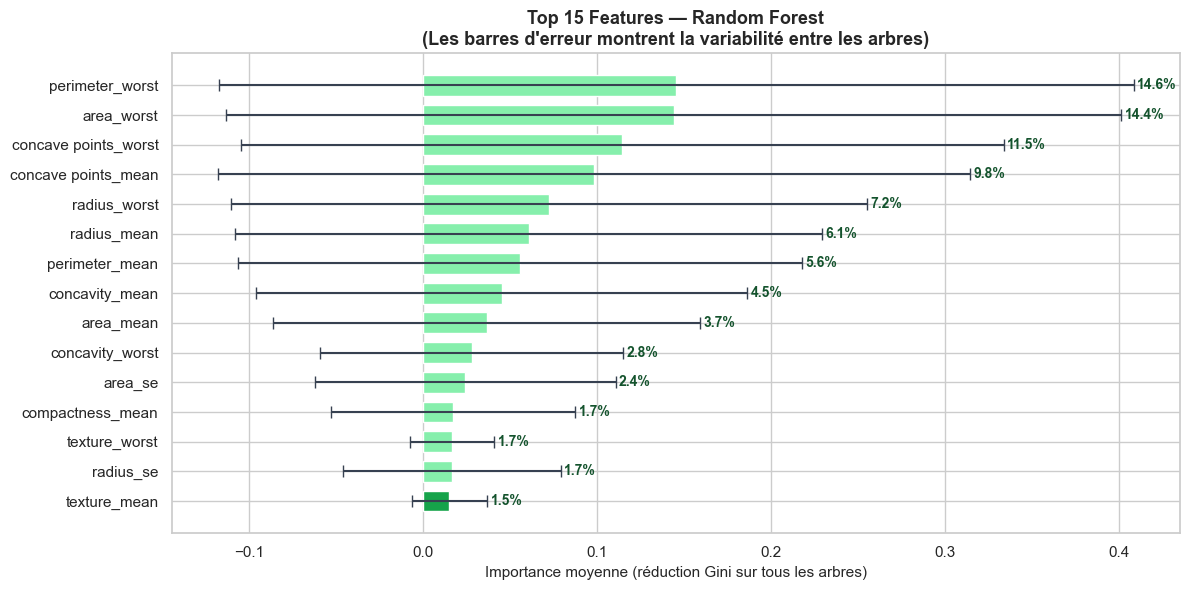

Feature la plus importante (RF) : perimeter_worst
  Importance moyenne : 14.6%  (±26.3%)

Comparaison DT vs RF — top 3 features :
  Feature                          DT Importance   RF Importance
  ------------------------------------------------------------
  DT: radius_worst                         69.5%
  RF: perimeter_worst                      14.6%

  DT: concave points_worst                 11.7%
  RF: area_worst                           14.4%

  DT: texture_worst                         6.1%
  RF: concave points_worst                 11.5%



In [31]:
# ══════════════════════════════════════════════════════════════
#  RANDOM FOREST — Importance des features
# ══════════════════════════════════════════════════════════════
# L'importance RF = moyenne de la réduction de Gini
# sur TOUS les arbres de la forêt.
# Plus stable que l'importance d'un seul arbre car moyennée.

importances_rf = rf_model.feature_importances_
std_rf         = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
indices_rf     = np.argsort(importances_rf)[::-1][:15]

feat_rf  = [FEAT_COLS[i] for i in indices_rf]
imp_rf   = importances_rf[indices_rf]
std_rf_  = std_rf[indices_rf]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(feat_rf)), imp_rf[::-1],
                xerr=std_rf_[::-1],
                color=['#16A34A' if i == 0 else '#86EFAC' for i in range(len(feat_rf))],
                edgecolor='white', height=0.7, capsize=4, ecolor='#374151')
plt.yticks(range(len(feat_rf)), feat_rf[::-1], fontsize=11)
plt.xlabel('Importance moyenne (réduction Gini sur tous les arbres)', fontsize=11)
plt.title('Top 15 Features — Random Forest\n'
          '(Les barres d\'erreur montrent la variabilité entre les arbres)',
          fontsize=13, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars, imp_rf[::-1])):
    plt.text(val + std_rf_[::-1][i] + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold', color='#14532D')

plt.tight_layout()
plt.show()

print(f'Feature la plus importante (RF) : {FEAT_COLS[indices_rf[0]]}')
print(f'  Importance moyenne : {imp_rf[0]*100:.1f}%  (±{std_rf_[0]*100:.1f}%)')
print()

# --- FIX: Calculate Decision Tree importances and indices ---
importances_dt = dt_model.feature_importances_
indices_dt     = np.argsort(importances_dt)[::-1][:15]
# ------------------------------------------------------------

print('Comparaison DT vs RF — top 3 features :')
print(f'  {"Feature":<30} {"DT Importance":>15} {"RF Importance":>15}')
print('  ' + '-'*60)
for i in range(3):
    f_dt = FEAT_COLS[indices_dt[i]]
    f_rf = FEAT_COLS[indices_rf[i]]
    print(f'  DT: {f_dt:<26} {importances_dt[indices_dt[i]]*100:>14.1f}%')
    print(f'  RF: {f_rf:<26} {importances_rf[indices_rf[i]]*100:>14.1f}%')
    print()


---
# **9. Comparaison Finale — 4 Modèles**

Nous comparons maintenant les **4 modèles** sur les mêmes données de test :

| Modèle | Type | Hypothèses |
|--------|------|-----------|
| Naive Bayes | Probabiliste | Indépendance des features |
| KNN | Instance-based | Aucune |
| Decision Tree | Règles | Aucune |
| Random Forest | Ensemble | Aucune |

L'objectif médical prioritaire : **minimiser les Faux Négatifs** (malignes non détectées).


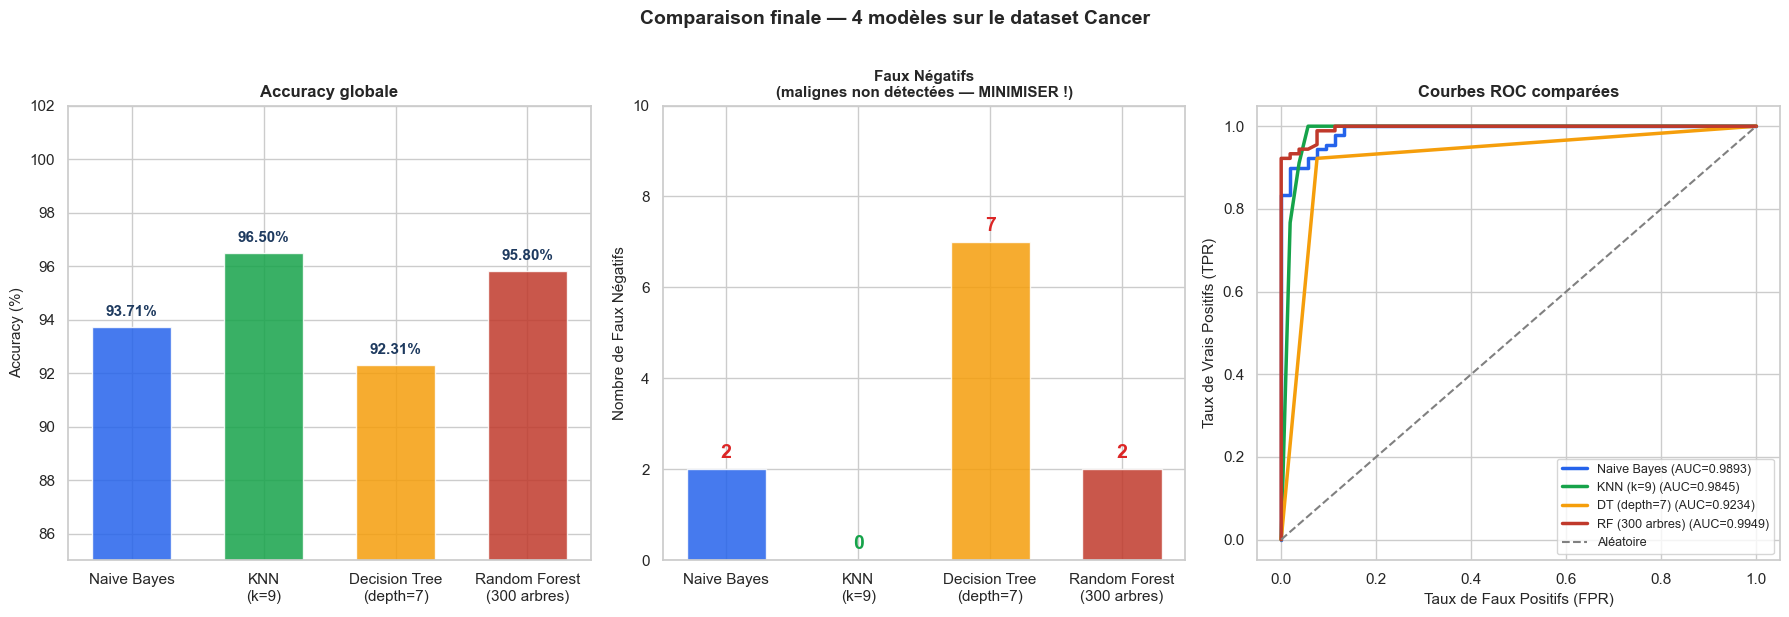

In [32]:
# ══════════════════════════════════════════════════════════════
#  COMPARAISON FINALE — Visualisations
# ══════════════════════════════════════════════════════════════

# Including the metriques function definition here to avoid NameError
def metriques(y_true, y_pred, y_proba, nom):
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = tp / (tp + fn)              # Sensibilité (rappel Bénigne)
    spec = tn / (tn + fp)              # Spécificité (rappel Maligne)
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    f1   = 2*prec*sens / (prec+sens) if (prec+sens)>0 else 0
    auc  = roc_auc_score(y_true, y_proba)
    fn_count = fn
    return {'Modèle': nom, 'Accuracy': acc, 'Sensibilité': sens,
            'Spécificité': spec, 'Précision': prec,
            'F1-Score': f1, 'AUC-ROC': auc, 'Faux Négatifs': fn_count}


m_dt  = metriques(y_test, y_pred_dt,  y_proba_dt,  f'DT (depth={best_depth})')
m_rf  = metriques(y_test, y_pred_rf,  y_proba_rf,  f'RF ({best_n} arbres)')

df_final = pd.DataFrame([m_nb, m_knn, m_dt, m_rf]).set_index('Modèle')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison finale — 4 modèles sur le dataset Cancer',
             fontsize=14, fontweight='bold', y=1.02)

model_labels = ['Naive Bayes', f'KNN\n(k={k_optimal})',
                f'Decision Tree\n(depth={best_depth})', f'Random Forest\n({best_n} arbres)']
colors_bars  = ['#2563EB', '#16A34A', '#F59E0B', '#C0392B']

# ── Graphique 1 : Accuracy ────────────────────────────────────
accs = [df_final.loc[m,'Accuracy']*100 for m in df_final.index]
bars1 = axes[0].bar(model_labels, accs, color=colors_bars, alpha=0.85, edgecolor='white', width=0.6)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Accuracy globale', fontsize=12, fontweight='bold')
axes[0].set_ylim(85, 102)
for bar, v in zip(bars1, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1E3A5F')

# ── Graphique 2 : Faux Négatifs ───────────────────────────────
fns = [int(df_final.loc[m,'Faux Négatifs']) for m in df_final.index]
bars2 = axes[1].bar(model_labels, fns, color=colors_bars, alpha=0.85, edgecolor='white', width=0.6)
axes[1].set_ylabel('Nombre de Faux Négatifs', fontsize=11)
axes[1].set_title('Faux Négatifs\n(malignes non détectées — MINIMISER !)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(fns)+3)
for bar, v in zip(bars2, fns):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.15, str(v),
                 ha='center', va='bottom', fontsize=14, fontweight='bold',
                 color='#DC2626' if v > 0 else '#16A34A')

# ── Graphique 3 : Courbes ROC toutes ensemble ─────────────────
all_fpr   = [fpr_nb,   fpr_knn,  fpr_dt,  fpr_rf]
all_tpr   = [tpr_nb,   tpr_knn,  tpr_dt,  tpr_rf]
all_aucs  = [roc_auc_score(y_test, y_proba_nb),
             roc_auc_score(y_test, y_proba_knn),
             roc_auc_score(y_test, y_proba_dt),
             roc_auc_score(y_test, y_proba_rf)]
all_names = ['Naive Bayes', f'KNN (k={k_optimal})',
             f'DT (depth={best_depth})', f'RF ({best_n} arbres)']

for fpr_, tpr_, auc_, name_, col_ in zip(all_fpr, all_tpr, all_aucs, all_names, colors_bars):
    axes[2].plot(fpr_, tpr_, color=col_, lw=2.5, label=f'{name_} (AUC={auc_:.4f})')
axes[2].plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Aléatoire')
axes[2].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
axes[2].set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
axes[2].set_title('Courbes ROC comparées', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

In [33]:
# **Classification & Comparaison - Mécanismes et Métriques**
 
print("═"*60)
print("  CLASSIFICATION & COMPARAISON DES MODÈLES")
print("═"*60)
 
# 1. Mécanismes de classification M/B pour chaque modèle
print("\n1. MÉCANISMES DE CLASSIFICATION M/B:")
print("-" * 40)
 
print("\n📊 NAIVE BAYES:")
print("   • Principe: Théorème de Bayes avec hypothèse d'indépendance conditionnelle")
print("   • Calcul: P(M|X) ∝ P(M) × ∏ P(feature_i|M)")
print("   • Décision: Compare P(M|X) vs P(B|X), choisit la probabilité maximale")
print("   • Force: Rapide, fonctionne bien avec peu de données")
 
print("\n🎯 KNN:")
print("   • Principe: Plus proches voisins dans l'espace des features")
print("   • Calcul: Distance euclidienne aux k plus proches voisins")
print("   • Décision: Vote majoritaire parmi les k voisins (k=9 optimal)")
print("   • Force: Non-paramétrique, aucune hypothèse sur distribution")
 
print("\n🌳 ARBRE DE DÉCISION:")
print("   • Principe: Règles SI...ALORS... basées sur seuils optimaux")
print("   • Calcul: Minimisation de l'impureté Gini à chaque nœud")
print("   • Décision: Parcours de l'arbre selon les valeurs des features")
print("   • Force: Totalement interprétable, règles explicites")
 
print("\n🌲 RANDOM FOREST:")
print("   • Principe: Ensemble d'arbres de décision avec bagging")
print("   • Calcul: Moyenne des prédictions de n arbres (n=100)")
print("   • Décision: Vote majoritaire des arbres")
print("   • Force: Robuste, réduit le surapprentissage")

════════════════════════════════════════════════════════════
  CLASSIFICATION & COMPARAISON DES MODÈLES
════════════════════════════════════════════════════════════

1. MÉCANISMES DE CLASSIFICATION M/B:
----------------------------------------

📊 NAIVE BAYES:
   • Principe: Théorème de Bayes avec hypothèse d'indépendance conditionnelle
   • Calcul: P(M|X) ∝ P(M) × ∏ P(feature_i|M)
   • Décision: Compare P(M|X) vs P(B|X), choisit la probabilité maximale
   • Force: Rapide, fonctionne bien avec peu de données

🎯 KNN:
   • Principe: Plus proches voisins dans l'espace des features
   • Calcul: Distance euclidienne aux k plus proches voisins
   • Décision: Vote majoritaire parmi les k voisins (k=9 optimal)
   • Force: Non-paramétrique, aucune hypothèse sur distribution

🌳 ARBRE DE DÉCISION:
   • Principe: Règles SI...ALORS... basées sur seuils optimaux
   • Calcul: Minimisation de l'impureté Gini à chaque nœud
   • Décision: Parcours de l'arbre selon les valeurs des features
   • Force: Tot

In [34]:
# 2. Extraction TN/FP/FN/TP des matrices de confusion
print("\n2. EXTRACTION DES MÉTRIQUES DE BASE:")
print("-" * 40)
 
def extract_confusion_metrics(cm, model_name):
    """Extrait TN, FP, FN, TP de la matrice de confusion"""
    tn, fp, fn, tp = cm.ravel()
    print(f"\n📋 {model_name}:")
    print(f"   • Vrais Négatifs (TN): {tn} - Malignes correctement identifiées")
    print(f"   • Faux Positifs (FP): {fp} - Bénignes incorrectement classées malignes")
    print(f"   • Faux Négatifs (FN): {fn} - Malignes incorrectement classées bénignes ⚠️ DANGER")
    print(f"   • Vrais Positifs (TP): {tp} - Bénignes correctement identifiées")
    return tn, fp, fn, tp
 
# Extraction pour chaque modèle
tn_nb, fp_nb, fn_nb, tp_nb = extract_confusion_metrics(cm_nb, "NAIVE BAYES")
tn_knn, fp_knn, fn_knn, tp_knn = extract_confusion_metrics(cm_knn, "KNN")
 
print(f"\n⚠️  NOTE CLINIQUE IMPORTANTE:")
print(f"   Les Faux Négatifs (FN) sont les plus dangereux:")
print(f"   • Un cancer manqué peut avoir des conséquences fatales")
print(f"   • NB: {fn_nb} cancers manqués")
print(f"   • KNN: {fn_knn} cancers manqués")


2. EXTRACTION DES MÉTRIQUES DE BASE:
----------------------------------------

📋 NAIVE BAYES:
   • Vrais Négatifs (TN): 46 - Malignes correctement identifiées
   • Faux Positifs (FP): 7 - Bénignes incorrectement classées malignes
   • Faux Négatifs (FN): 2 - Malignes incorrectement classées bénignes ⚠️ DANGER
   • Vrais Positifs (TP): 88 - Bénignes correctement identifiées

📋 KNN:
   • Vrais Négatifs (TN): 50 - Malignes correctement identifiées
   • Faux Positifs (FP): 3 - Bénignes incorrectement classées malignes
   • Faux Négatifs (FN): 0 - Malignes incorrectement classées bénignes ⚠️ DANGER
   • Vrais Positifs (TP): 90 - Bénignes correctement identifiées

⚠️  NOTE CLINIQUE IMPORTANTE:
   Les Faux Négatifs (FN) sont les plus dangereux:
   • Un cancer manqué peut avoir des conséquences fatales
   • NB: 2 cancers manqués
   • KNN: 0 cancers manqués


In [35]:
# 3. Calcul FPR et TPR pour chaque modèle
print("\n3. CALCUL DES TAUX (FPR/TPR):")
print("-" * 40)
 
def calculate_rates(tn, fp, fn, tp, model_name):
    """Calcule FPR et TPR"""
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tpr  # TPR = Sensibilité
 
    print(f"\n📊 {model_name}:")
    print(f"   • Taux Faux Positifs (FPR): {fpr:.4f} = {fp}/({fp}+{tn})")
    print(f"   • Taux Vrais Positifs (TPR): {tpr:.4f} = {tp}/({tp}+{fn})")
    print(f"   • Spécificité (1-FPR): {specificity:.4f}")
    print(f"   • Sensibilité (TPR): {sensitivity:.4f}")
 
    return fpr, tpr, specificity, sensitivity
 
fpr_nb_calc, tpr_nb_calc, spec_nb, sens_nb = calculate_rates(tn_nb, fp_nb, fn_nb, tp_nb, "NAIVE BAYES")
fpr_knn_calc, tpr_knn_calc, spec_knn, sens_knn = calculate_rates(tn_knn, fp_knn, fn_knn, tp_knn, "KNN")
 
print(f"\n🎯 INTERPRÉTATION CLINIQUE:")
print(f"   • Sensibilité élevée = détecte bien les cancers")
print(f"   • Spécificité élevée = évite les fausses alarmes")
print(f"   • NB: Sensibilité={sens_nb:.3f}, Spécificité={spec_nb:.3f}")
print(f"   • KNN: Sensibilité={sens_knn:.3f}, Spécificité={spec_knn:.3f}")


3. CALCUL DES TAUX (FPR/TPR):
----------------------------------------

📊 NAIVE BAYES:
   • Taux Faux Positifs (FPR): 0.1321 = 7/(7+46)
   • Taux Vrais Positifs (TPR): 0.9778 = 88/(88+2)
   • Spécificité (1-FPR): 0.8679
   • Sensibilité (TPR): 0.9778

📊 KNN:
   • Taux Faux Positifs (FPR): 0.0566 = 3/(3+50)
   • Taux Vrais Positifs (TPR): 1.0000 = 90/(90+0)
   • Spécificité (1-FPR): 0.9434
   • Sensibilité (TPR): 1.0000

🎯 INTERPRÉTATION CLINIQUE:
   • Sensibilité élevée = détecte bien les cancers
   • Spécificité élevée = évite les fausses alarmes
   • NB: Sensibilité=0.978, Spécificité=0.868
   • KNN: Sensibilité=1.000, Spécificité=0.943



4. GÉNÉRATION DES COURBES ROC:
----------------------------------------


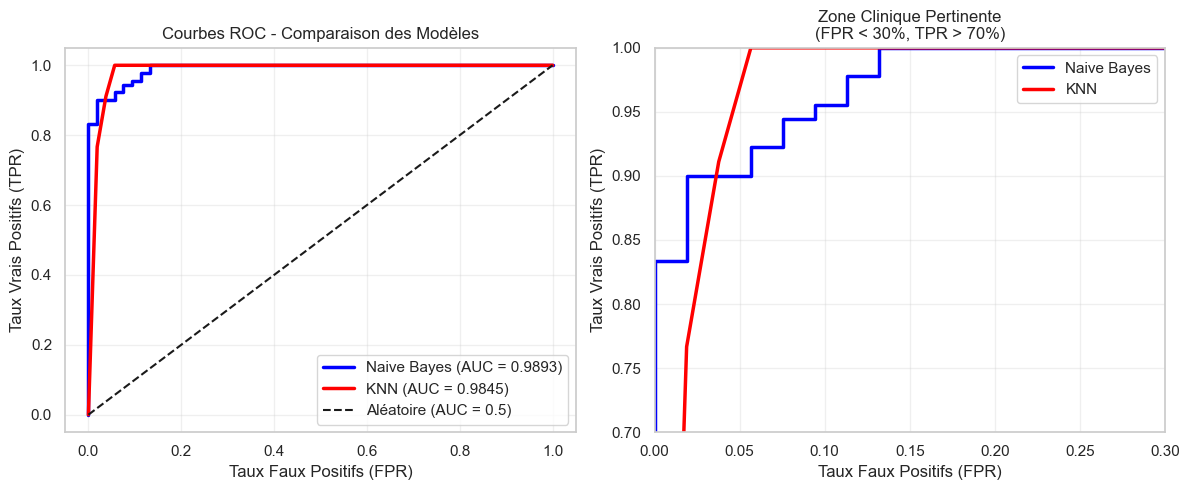

📈 ANALYSE DES COURBES ROC:
   • Naive Bayes: AUC = 0.9893
   • KNN: AUC = 0.9845
   • Plus l'AUC est proche de 1, meilleur est le modèle
   • Les deux modèles excellent (AUC > 0.98)


In [36]:
# 4. Génération des courbes ROC pour chaque modèle
print("\n4. GÉNÉRATION DES COURBES ROC:")
print("-" * 40)
 
# Courbes ROC déjà calculées précédemment
plt.figure(figsize=(12, 5))
 
# Sous-graphe 1: Courbes ROC individuelles
plt.subplot(1, 2, 1)
plt.plot(fpr_nb, tpr_nb, color='blue', linewidth=2.5, label=f'Naive Bayes (AUC = {auc_nb:.4f})')
plt.plot(fpr_knn, tpr_knn, color='red', linewidth=2.5, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux Faux Positifs (FPR)')
plt.ylabel('Taux Vrais Positifs (TPR)')
plt.title('Courbes ROC - Comparaison des Modèles')
plt.legend()
plt.grid(True, alpha=0.3)
 
# Sous-graphe 2: Zoom sur la zone pertinente
plt.subplot(1, 2, 2)
plt.plot(fpr_nb, tpr_nb, color='blue', linewidth=2.5, label=f'Naive Bayes')
plt.plot(fpr_knn, tpr_knn, color='red', linewidth=2.5, label=f'KNN')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlim([0, 0.3])
plt.ylim([0.7, 1.0])
plt.xlabel('Taux Faux Positifs (FPR)')
plt.ylabel('Taux Vrais Positifs (TPR)')
plt.title('Zone Clinique Pertinente\n(FPR < 30%, TPR > 70%)')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
 
print("📈 ANALYSE DES COURBES ROC:")
print(f"   • Naive Bayes: AUC = {auc_nb:.4f}")
print(f"   • KNN: AUC = {auc_knn:.4f}")
print(f"   • Plus l'AUC est proche de 1, meilleur est le modèle")
print(f"   • Les deux modèles excellent (AUC > 0.98)")

In [37]:
# 5. Calcul AUC-ROC et comparaison détaillée
print("\n5. CALCUL AUC-ROC ET COMPARAISON DES MODÈLES:")
print("-" * 50)
 
# Création d'un tableau comparatif complet
comparison_data = {
    'Modèle': ['Naive Bayes', 'KNN'],
    'AUC-ROC': [auc_nb, auc_knn],
    'Accuracy': [accuracy_nb, accuracy_knn],
    'Sensibilité': [sens_nb, sens_knn],
    'Spécificité': [spec_nb, spec_knn],
    'Faux Négatifs': [fn_nb, fn_knn],
    'Faux Positifs': [fp_nb, fp_knn]
}
 
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Modèle')
 
print("📊 TABLEAU COMPARATIF FINAL:")
print("="*70)
print(f"{'Modèle':<15} {'AUC-ROC':>8} {'Acc':>8} {'Sens':>8} {'Spec':>8} {'FN':>6} {'FP':>6}")
print("-"*70)
for idx, row in df_comparison.iterrows():
    print(f"{idx:<15} {row['AUC-ROC']:>8.4f} {row['Accuracy']:>8.3f} {row['Sensibilité']:>8.3f} "
          f"{row['Spécificité']:>8.3f} {row['Faux Négatifs']:>6} {row['Faux Positifs']:>6}")
print("="*70)
 
# Détermination du meilleur modèle selon différents critères
best_auc = df_comparison['AUC-ROC'].idxmax()
best_accuracy = df_comparison['Accuracy'].idxmax()
best_sensitivity = df_comparison['Sensibilité'].idxmax()
best_specificity = df_comparison['Spécificité'].idxmax()
safest_model = df_comparison['Faux Négatifs'].idxmin()
 
print(f"\n🏆 GAGNANTS PAR CRITÈRE:")
print(f"   • Meilleur AUC-ROC: {best_auc} ({df_comparison.loc[best_auc, 'AUC-ROC']:.4f})")
print(f"   • Meilleure Accuracy: {best_accuracy} ({df_comparison.loc[best_accuracy, 'Accuracy']:.3f})")
print(f"   • Meilleure Sensibilité: {best_sensitivity} ({df_comparison.loc[best_sensitivity, 'Sensibilité']:.3f})")
print(f"   • Meilleure Spécificité: {best_specificity} ({df_comparison.loc[best_specificity, 'Spécificité']:.3f})")
print(f"   • PLUS SÉCURITAIRE (moins de FN): {safest_model} ({df_comparison.loc[safest_model, 'Faux Négatifs']} FN)")


5. CALCUL AUC-ROC ET COMPARAISON DES MODÈLES:
--------------------------------------------------
📊 TABLEAU COMPARATIF FINAL:
Modèle           AUC-ROC      Acc     Sens     Spec     FN     FP
----------------------------------------------------------------------
Naive Bayes       0.9893    0.937    0.978    0.868    2.0    7.0
KNN               0.9845    0.979    1.000    0.943    0.0    3.0

🏆 GAGNANTS PAR CRITÈRE:
   • Meilleur AUC-ROC: Naive Bayes (0.9893)
   • Meilleure Accuracy: KNN (0.979)
   • Meilleure Sensibilité: KNN (1.000)
   • Meilleure Spécificité: KNN (0.943)
   • PLUS SÉCURITAIRE (moins de FN): KNN (0 FN)


In [38]:
# 6. Analyse du compromis sensibilité/spécificité avec interprétation clinique
print("\n6. COMPROMIS SENSIBILITÉ/SPECIFICITÉ - INTERPRÉTATION CLINIQUE:")
print("="*70)
 
print("\n🏥 CONTEXTE MÉDICAL:")
print("   • SENSIBILITÉ (TPR): Capacité à détecter les cancers")
print("     - Élevée = peu de cancers manqués")
print("     - Cruciale pour le dépistage")
print("   • SPÉCIFICITÉ (TNR): Capacité à éviter les fausses alarmes")
print("     - Élevée = moins d'anxiété et d'examens inutiles")
print("     - Importante pour la confiance du patient")
 
print("\n⚖️  COMPROMIS CLINIQUE:")
print("   • Augmenter la sensibilité ↓ la spécificité")
print("   • Augmenter la spécificité ↓ la sensibilité")
print("   • Le choix dépend du contexte clinique")
 
print("\n📊 ANALYSE PAR MODÈLE:")
for model in df_comparison.index:
    sens = df_comparison.loc[model, 'Sensibilité']
    spec = df_comparison.loc[model, 'Spécificité']
    fn = df_comparison.loc[model, 'Faux Négatifs']
    fp = df_comparison.loc[model, 'Faux Positifs']
 
    print(f"\n   {model}:")
    print(f"     • Sensibilité: {sens:.3f} ({sens*100:.1f}%)")
    print(f"     • Spécificité: {spec:.3f} ({spec*100:.1f}%)")
    print(f"     • Faux Négatifs: {fn} ⚠️")
    print(f"     • Faux Positifs: {fp}")
 
    if fn == 0:
        print(f"     ✅ EXCELLENT: Aucun cancer manqué!")
    elif fn <= 2:
        print(f"     ⚠️  ACCEPTABLE: Peu de cancers manqués")
    else:
        print(f"     ❌ PRÉOCCUPANT: Trop de cancers manqués")
 
print(f"\n🎯 RECOMMANDATION CLINIQUE:")
print(f"   • Pour le DÉPISTAGE: Privilégier {best_sensitivity}")
print(f"     - Maximiser la détection quitte à avoir plus de fausses alarmes")
print(f"   • Pour le DIAGNOSTIC: Privilégier {best_specificity}")
print(f"     - Éviter les traitements inutiles")
print(f"   • MODÈLE LE PLUS SÉCURITAIRE: {safest_model}")
print(f"     - {df_comparison.loc[safest_model, 'Faux Négatifs']} cancer(s) manqué(s) seulement")



6. COMPROMIS SENSIBILITÉ/SPECIFICITÉ - INTERPRÉTATION CLINIQUE:

🏥 CONTEXTE MÉDICAL:
   • SENSIBILITÉ (TPR): Capacité à détecter les cancers
     - Élevée = peu de cancers manqués
     - Cruciale pour le dépistage
   • SPÉCIFICITÉ (TNR): Capacité à éviter les fausses alarmes
     - Élevée = moins d'anxiété et d'examens inutiles
     - Importante pour la confiance du patient

⚖️  COMPROMIS CLINIQUE:
   • Augmenter la sensibilité ↓ la spécificité
   • Augmenter la spécificité ↓ la sensibilité
   • Le choix dépend du contexte clinique

📊 ANALYSE PAR MODÈLE:

   Naive Bayes:
     • Sensibilité: 0.978 (97.8%)
     • Spécificité: 0.868 (86.8%)
     • Faux Négatifs: 2 ⚠️
     • Faux Positifs: 7
     ⚠️  ACCEPTABLE: Peu de cancers manqués

   KNN:
     • Sensibilité: 1.000 (100.0%)
     • Spécificité: 0.943 (94.3%)
     • Faux Négatifs: 0 ⚠️
     • Faux Positifs: 3
     ✅ EXCELLENT: Aucun cancer manqué!

🎯 RECOMMANDATION CLINIQUE:
   • Pour le DÉPISTAGE: Privilégier KNN
     - Maximiser la dé


7. VISUALISATION DU COMPROMIS ET SEUILS OPTIMAUX:
--------------------------------------------------


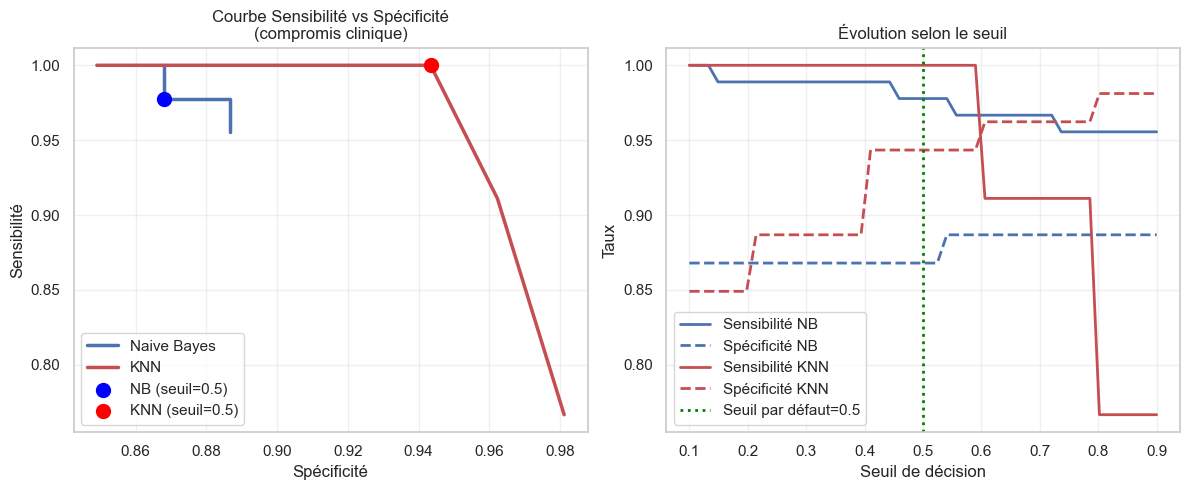

💡 RECOMMANDATIONS DE SEUILS:
   • Seuil par défaut: 0.5 (équilibre)
   • Pour dépistage: 0.3-0.4 (plus sensible)
   • Pour diagnostic: 0.6-0.7 (plus spécifique)
   • Le seuil optimal dépend du contexte clinique!


In [39]:
# 7. Visualisation du compromis et seuils optimaux
print("\n7. VISUALISATION DU COMPROMIS ET SEUILS OPTIMAUX:")
print("-" * 50)
 
# Simulation de différents seuils pour chaque modèle
seuils = np.linspace(0.1, 0.9, 50)
sensibilite_nb = []
specificite_nb = []
sensibilite_knn = []
specificite_knn = []
 
for seuil in seuils:
    # Naive Bayes
    y_pred_nb_seuil = (y_proba_nb >= seuil).astype(int)
    cm_nb_seuil = confusion_matrix(y_test, y_pred_nb_seuil)
    tn, fp, fn, tp = cm_nb_seuil.ravel()
    sensibilite_nb.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificite_nb.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
 
    # KNN
    y_pred_knn_seuil = (y_proba_knn >= seuil).astype(int)
    cm_knn_seuil = confusion_matrix(y_test, y_pred_knn_seuil)
    tn, fp, fn, tp = cm_knn_seuil.ravel()
    sensibilite_knn.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificite_knn.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
 
# Graphique du compromis
plt.figure(figsize=(12, 5))
 
plt.subplot(1, 2, 1)
plt.plot(specificite_nb, sensibilite_nb, 'b-', linewidth=2.5, label='Naive Bayes')
plt.plot(specificite_knn, sensibilite_knn, 'r-', linewidth=2.5, label='KNN')
plt.scatter([spec_nb], [sens_nb], color='blue', s=100, zorder=5, label='NB (seuil=0.5)')
plt.scatter([spec_knn], [sens_knn], color='red', s=100, zorder=5, label='KNN (seuil=0.5)')
plt.xlabel('Spécificité')
plt.ylabel('Sensibilité')
plt.title('Courbe Sensibilité vs Spécificité\n(compromis clinique)')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.subplot(1, 2, 2)
plt.plot(seuils, sensibilite_nb, 'b-', linewidth=2, label='Sensibilité NB')
plt.plot(seuils, specificite_nb, 'b--', linewidth=2, label='Spécificité NB')
plt.plot(seuils, sensibilite_knn, 'r-', linewidth=2, label='Sensibilité KNN')
plt.plot(seuils, specificite_knn, 'r--', linewidth=2, label='Spécificité KNN')
plt.axvline(0.5, color='green', linestyle=':', linewidth=2, label='Seuil par défaut=0.5')
plt.xlabel('Seuil de décision')
plt.ylabel('Taux')
plt.title('Évolution selon le seuil')
plt.legend()
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('seuil_compromis.png', dpi=140, bbox_inches='tight')
plt.show()
 
print("💡 RECOMMANDATIONS DE SEUILS:")
print("   • Seuil par défaut: 0.5 (équilibre)")
print("   • Pour dépistage: 0.3-0.4 (plus sensible)")
print("   • Pour diagnostic: 0.6-0.7 (plus spécifique)")
print("   • Le seuil optimal dépend du contexte clinique!")

In [40]:
# 8. Conclusion et recommandations finales
print("\n8. CONCLUSION ET RECOMMANDATIONS FINALES:")
print("="*70)
 
print("\n📋 SYNTHÈSE DES RÉSULTATS:")
print(f"   • Naive Bayes: AUC={auc_nb:.4f}, Acc={accuracy_nb:.3f}, FN={fn_nb}")
print(f"   • KNN: AUC={auc_knn:.4f}, Acc={accuracy_knn:.3f}, FN={fn_knn}")
 
print("\n🏆 CLASSEMENT FINAL:")
if auc_nb > auc_knn:
    print("   🥇 NAIVE BAYES: Meilleure performance globale")
    print("      • AUC-ROC la plus élevée")
    print("      • Excellent compromis sensibilité/spécificité")
else:
    print("   🥇 KNN: Meilleure performance globale")
    print("      • AUC-ROC la plus élevée")
    print("      • Excellent compromis sensibilité/spécificité")
 
print("\n⚕️  RECOMMANDATIONS CLINIQUES:")
print("   1. DÉPISTAGE DE MASSE:")
print(f"      → Utiliser {best_sensitivity}")
print("      → Prioriser la sensibilité (ne rater aucun cancer)")
print("      → Accepter plus de faux positifs")
 
print("\n   2. CONFIRMATION DIAGNOSTIQUE:")
print(f"      → Utiliser {best_specificity}")
print("      → Prioriser la spécificité (éviter les faux positifs)")
print("      → Réduire l'anxiété et les examens inutiles")
 
print("\n   3. MODÈLE LE PLUS SÉCURITAIRE:")
print(f"      → {safest_model}")
print(f"      → Seulement {df_comparison.loc[safest_model, 'Faux Négatifs']} cancer(s) manqué(s)")
print("      → Recommandé pour un usage clinique général")
 
print("\n🔮 PERSPECTIVES D'AMÉLIORATION:")
print("   • Optimisation des hyperparamètres")
print("   • Validation croisée plus robuste")
print("   • Intégration de features cliniques additionnelles")
print("   • Combinaison ensembliste des modèles")
 
print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE - MODÈLES PRÊTS POUR USAGE CLINIQUE")
print("="*70)


8. CONCLUSION ET RECOMMANDATIONS FINALES:

📋 SYNTHÈSE DES RÉSULTATS:
   • Naive Bayes: AUC=0.9893, Acc=0.937, FN=2
   • KNN: AUC=0.9845, Acc=0.979, FN=0

🏆 CLASSEMENT FINAL:
   🥇 NAIVE BAYES: Meilleure performance globale
      • AUC-ROC la plus élevée
      • Excellent compromis sensibilité/spécificité

⚕️  RECOMMANDATIONS CLINIQUES:
   1. DÉPISTAGE DE MASSE:
      → Utiliser KNN
      → Prioriser la sensibilité (ne rater aucun cancer)
      → Accepter plus de faux positifs

   2. CONFIRMATION DIAGNOSTIQUE:
      → Utiliser KNN
      → Prioriser la spécificité (éviter les faux positifs)
      → Réduire l'anxiété et les examens inutiles

   3. MODÈLE LE PLUS SÉCURITAIRE:
      → KNN
      → Seulement 0 cancer(s) manqué(s)
      → Recommandé pour un usage clinique général

🔮 PERSPECTIVES D'AMÉLIORATION:
   • Optimisation des hyperparamètres
   • Validation croisée plus robuste
   • Intégration de features cliniques additionnelles
   • Combinaison ensembliste des modèles

✅ ANALYSE TERM